<a href="https://colab.research.google.com/github/tousifo/ml_notebooks/blob/main/QMedShield_FIBA_PathMNIST_QSentry_PATCHED_v5_QUANTUM_DETECTION_REBUILD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QMedShield FIBA / PathMNIST QSentry-style Extension

Scope lock: this notebook runs **FIBA-style attack on PathMNIST only**. It does not run Blend. Do not report FIBA detection until ASR passes the gate.

## Audit summary before split

| Section | Current Purpose | Shared / Blend-only / FIBA-only | Keep / Move / Fix / Remove | Reason |
|---|---|---|---|---|
| Imports/seed/device | Runtime setup | Shared | Keep | Required by both split notebooks |
| Dataset loading | MedMNIST loading | Shared | Keep | PathMNIST only in this notebook |
| Model architecture | ResNet-18 → BiGRU → VQC | Shared | Keep | Core QMedShield architecture |
| Training/evaluation | Train poisoned QNN/classical baseline | Shared | Keep | Attack-specific poisoned dataset is FIBA here |
| Blend trigger | Pixel-global attack | Blend-only | Remove | Prevent cross-contamination |
| FIBA trigger | Low-frequency amplitude injection | FIBA-only | Keep + fix | Applied after resizing to 96×96 |
| Feature ablation | Raw/classical/QNN/quantum/QMRS | Shared | Keep + fix | Removes duplicate CC-QMC and splits QMRS |
| Output saving | CSV/plots/claim report | FIBA-only | Fix | Saves only to outputs_fiba_pathmnist |


In [1]:
# ============================================================
# Imports, configuration, reproducibility — FIBA / PathMNIST
# ============================================================

import os, sys, json, math, random, subprocess
from dataclasses import dataclass, asdict
from typing import Optional, Tuple
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import torchvision.transforms as T
from torchvision import models
from torchvision.models import ResNet18_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, average_precision_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA, PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

INSTALL_MISSING_PACKAGES = True

def ensure_package(import_name, pip_name=None):
    try:
        return __import__(import_name)
    except ImportError:
        if not INSTALL_MISSING_PACKAGES:
            raise
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])
        return __import__(import_name)

medmnist = ensure_package("medmnist")
from medmnist import INFO
qml = ensure_package("pennylane")

ATTACK_NAME = "fiba"
DATASET_NAME = "pathmnist"
RUN_DERMAMNIST_BLEND = False
RUN_PATHMNIST_FIBA = True
RUN_CLASSICAL_POISONED_BASELINE = True
RUN_PAIR_SELECTION = True

DEFAULT_OUT_DIR = "/kaggle/working/outputs_fiba_pathmnist" if os.path.exists("/kaggle/working") else "/mnt/data/outputs_fiba_pathmnist" if os.path.exists("/mnt/data") else "./outputs_fiba_pathmnist"

CANDIDATE_PAIRS_FIBA = [(0, 5), (1, 5), (2, 5), (3, 5), (8, 5), (4, 7)]

@dataclass
class QMedShieldFIBAConfig:
    primary_seed: int = 42
    dataset_name: str = DATASET_NAME
    attack_type: str = ATTACK_NAME
    n_classes: int = 9
    native_image_size: int = 28
    model_image_size: int = 96
    source_class: Optional[int] = None
    target_class: Optional[int] = None
    max_train_n: int = 6000
    pilot_max_train_n: int = 1500
    max_clean_test_n: int = 1200
    max_asr_n: int = 800
    val_size: float = 0.15
    use_imagenet_weights: bool = True
    freeze_resnet_lower_blocks: bool = True
    n_qubits: int = 8
    vqc_layers: int = 4
    obs_mode: str = "ZX_ALT"
    train_batch_size: int = 48
    eval_batch_size: int = 96
    clean_epochs: int = 8
    pilot_epochs: int = 2
    lr_base: float = 5e-4
    weight_decay: float = 1e-4
    label_smoothing: float = 0.10
    clean_acc_min: float = 0.50
    asr_min: float = 0.80
    strict_attack_gate: bool = True
    ica_components: int = 4
    kmeans_n_init: int = 10
    fpr_target: float = 0.05
    k_values: Tuple[int, ...] = (3, 5, 8, 10)
    threshold_method: str = "clean_val_95pct"
    clean_source_n: int = 450
    clean_target_n: int = 500
    poison_n: int = 50
    fiba_strength: float = 0.35
    fiba_strength_values: Tuple[float, ...] = (0.35, 0.25, 0.18)
    fiba_poison_rate: float = 0.15
    fiba_low_freq_radius: int = 10
    out_dir: str = DEFAULT_OUT_DIR

cfg = QMedShieldFIBAConfig()
os.makedirs(cfg.out_dir, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NEEDS_VERIFICATION = []
PLANNED_PENDING = []

assert ATTACK_NAME == "fiba"
assert DATASET_NAME == "pathmnist"
assert RUN_DERMAMNIST_BLEND is False
assert RUN_PATHMNIST_FIBA is True
assert cfg.attack_type == "fiba" and cfg.dataset_name == "pathmnist"


def set_all_seeds(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(cfg.primary_seed)
print("Device:", DEVICE)
print("Output directory:", cfg.out_dir)
display(pd.DataFrame([asdict(cfg)]).T.rename(columns={0: "value"}))


Device: cpu
Output directory: ./outputs_fiba_pathmnist


,value
primary_seed,42
dataset_name,pathmnist
attack_type,fiba
n_classes,9
native_image_size,28
model_image_size,96
source_class,None
target_class,None
max_train_n,6000
pilot_max_train_n,1500


In [2]:
# ============================================================
# Dataset loading utilities
# ============================================================

def load_medmnist_split(dataset_name: str, split: str, download: bool = True):
    info = INFO[dataset_name]
    DataClass = getattr(medmnist, info["python_class"])
    ds = DataClass(split=split, download=download)
    X = torch.tensor(ds.imgs, dtype=torch.float32)
    if X.ndim == 3:
        X = X.unsqueeze(-1)
    X = X.permute(0, 3, 1, 2) / 255.0
    if X.shape[1] == 1:
        X = X.repeat(1, 3, 1, 1)
    y = torch.tensor(ds.labels.squeeze(), dtype=torch.long)
    return X, y, info


def label_map_to_int(label_map):
    out = {}
    for k, v in label_map.items():
        name = v[0] if isinstance(v, (list, tuple)) else str(v)
        out[int(k)] = name
    return out


def load_dataset_bundle(dataset_name: str):
    X_train, y_train, info = load_medmnist_split(dataset_name, "train")
    X_val, y_val, _ = load_medmnist_split(dataset_name, "val")
    X_test, y_test, _ = load_medmnist_split(dataset_name, "test")
    class_map = label_map_to_int(info["label"])
    print(f"Loaded {dataset_name}: train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")
    display(pd.DataFrame([{"class_id": k, "class_name": v} for k, v in class_map.items()]))
    return {"X_train": X_train, "y_train": y_train, "X_val": X_val, "y_val": y_val, "X_test": X_test, "y_test": y_test, "class_map": class_map, "info": info}


def resize_tensor_images(X, size):
    if X.shape[-1] == size and X.shape[-2] == size:
        return X.float()
    return F.interpolate(X.float(), size=(size, size), mode="bilinear", align_corners=False)


def clone_cfg(base_cfg, **updates):
    data = asdict(base_cfg)
    data.update(updates)
    return type(base_cfg)(**data)


In [3]:
# ============================================================
# Model architecture and training helpers
# ============================================================

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)


def preprocess_for_resnet(x, model_image_size):
    x = F.interpolate(x, size=(model_image_size, model_image_size), mode="bilinear", align_corners=False)
    return (x - IMAGENET_MEAN.to(x.device)) / IMAGENET_STD.to(x.device)


def measurement_dim(n_qubits, obs_mode):
    obs = obs_mode.upper().strip()
    if obs in ["Z_ONLY", "ZX_ALT"]:
        return n_qubits
    if obs == "XYZ":
        return 3 * n_qubits
    raise ValueError(f"Unknown obs_mode={obs_mode}")


def make_vqc_qnode(n_qubits, n_layers, obs_mode="ZX_ALT"):
    try:
        dev = qml.device("lightning.qubit", wires=n_qubits)
    except Exception:
        print("[warning] lightning.qubit unavailable; using default.qubit")
        dev = qml.device("default.qubit", wires=n_qubits)
    obs = obs_mode.upper().strip()

    @qml.qnode(dev, interface="torch", diff_method="best")
    def circuit(angles, weights, input_scales, input_bias, trojan_angles, trigger_flag):
        for layer in range(n_layers):
            for q in range(n_qubits):
                qml.Rot(weights[layer, q, 0], weights[layer, q, 1], weights[layer, q, 2], wires=q)
            for q in range(n_qubits):
                qml.RY(input_scales[layer, q] * angles[q] + input_bias[layer, q], wires=q)
            # No QTrojan is used in this notebook; trigger_flag stays 0. This parameter remains only because the shared VQC layer supports QTrojan notebooks.
            for q in range(n_qubits):
                qml.RY(trigger_flag * trojan_angles[layer, q], wires=q)
            if layer % 2 == 0:
                for q in range(n_qubits):
                    qml.CNOT(wires=[q, (q + 1) % n_qubits])
            else:
                for q in range(n_qubits):
                    qml.CNOT(wires=[(q + 1) % n_qubits, q])
        if obs == "Z_ONLY":
            return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
        if obs == "XYZ":
            out = []
            for q in range(n_qubits):
                out.extend([qml.expval(qml.PauliX(q)), qml.expval(qml.PauliY(q)), qml.expval(qml.PauliZ(q))])
            return out
        return [qml.expval(qml.PauliZ(q)) if q % 2 == 0 else qml.expval(qml.PauliX(q)) for q in range(n_qubits)]
    return circuit


class StrongVQCMeasurementLayer(nn.Module):
    def __init__(self, in_dim, n_qubits, n_layers, obs_mode, trojan_init_std=0.0):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.obs_mode = obs_mode
        self.compress = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, 32),
            nn.Tanh(),
            nn.Linear(32, n_qubits),
            nn.Tanh(),
        )
        self.weights = nn.Parameter(0.01 * torch.randn(n_layers, n_qubits, 3))
        self.input_scales = nn.Parameter(torch.ones(n_layers, n_qubits))
        self.input_bias = nn.Parameter(torch.zeros(n_layers, n_qubits))
        self.trojan_angles = nn.Parameter(trojan_init_std * torch.randn(n_layers, n_qubits))
        self.qnode = make_vqc_qnode(n_qubits, n_layers, obs_mode)

    def forward(self, context, trojan_mask=None):
        angles = math.pi * (self.compress(context) + 1.0) / 2.0
        if trojan_mask is None:
            trojan_mask = torch.zeros(angles.shape[0], device=angles.device, dtype=angles.dtype)
        else:
            trojan_mask = trojan_mask.to(device=angles.device, dtype=angles.dtype).view(-1)
        vals = [
            torch.stack(self.qnode(a, self.weights, self.input_scales, self.input_bias, self.trojan_angles, flag)).float()
            for a, flag in zip(angles, trojan_mask)
        ]
        return torch.stack(vals, dim=0)


class QMedShieldHybridQNN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        weights = None
        if cfg.use_imagenet_weights:
            try:
                weights = ResNet18_Weights.IMAGENET1K_V1
            except Exception:
                weights = None
        try:
            resnet = models.resnet18(weights=weights)
        except Exception as exc:
            msg = f"needs verification: ImageNet weights unavailable ({exc}); using random ResNet-18 init."
            print("[warning]", msg)
            NEEDS_VERIFICATION.append(msg)
            resnet = models.resnet18(weights=None)
        self.stem = nn.Sequential(*list(resnet.children())[:-2])
        if cfg.freeze_resnet_lower_blocks:
            for p in self.stem[:6].parameters():
                p.requires_grad = False
        self.rnn = nn.GRU(input_size=512, hidden_size=256, num_layers=2, batch_first=True, bidirectional=True, dropout=0.2)
        self.vqc = StrongVQCMeasurementLayer(512, cfg.n_qubits, cfg.vqc_layers, cfg.obs_mode, 0.0)
        self.q_head = nn.Linear(measurement_dim(cfg.n_qubits, cfg.obs_mode), cfg.n_classes)

    def _context(self, x_preprocessed):
        feats = self.stem(x_preprocessed)
        B, C, H, W = feats.shape
        seq = feats.view(B, C, H*W).permute(0, 2, 1)
        out, _ = self.rnn(seq)
        return out.mean(dim=1)

    def forward(self, x_preprocessed, t=0.0, return_measurements=False):
        ctx = self._context(x_preprocessed)
        mask = torch.zeros(ctx.shape[0], device=ctx.device, dtype=ctx.dtype)
        qfeat = self.vqc(ctx, trojan_mask=mask)
        logits = self.q_head(qfeat)
        if return_measurements:
            return logits, qfeat, ctx
        return logits


class ClassicalResNetBiGRU(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        weights = None
        if cfg.use_imagenet_weights:
            try:
                weights = ResNet18_Weights.IMAGENET1K_V1
            except Exception:
                weights = None
        try:
            resnet = models.resnet18(weights=weights)
        except Exception:
            resnet = models.resnet18(weights=None)
        self.stem = nn.Sequential(*list(resnet.children())[:-2])
        if cfg.freeze_resnet_lower_blocks:
            for p in self.stem[:6].parameters():
                p.requires_grad = False
        self.rnn = nn.GRU(input_size=512, hidden_size=256, num_layers=2, batch_first=True, bidirectional=True, dropout=0.2)
        self.head = nn.Linear(512, cfg.n_classes)

    def _context(self, x_preprocessed):
        feats = self.stem(x_preprocessed)
        B, C, H, W = feats.shape
        seq = feats.view(B, C, H*W).permute(0, 2, 1)
        out, _ = self.rnn(seq)
        return out.mean(dim=1)

    def forward(self, x_preprocessed, return_context=False):
        ctx = self._context(x_preprocessed)
        logits = self.head(ctx)
        if return_context:
            return logits, ctx
        return logits


def verify_architecture(model, cfg, device):
    model = model.to(device)
    dummy = torch.rand(4, 3, cfg.native_image_size, cfg.native_image_size, device=device)
    xp = preprocess_for_resnet(dummy, cfg.model_image_size)
    logits, qfeat, ctx = model(xp, return_measurements=True)
    assert logits.shape == (4, cfg.n_classes), logits.shape
    assert qfeat.shape == (4, measurement_dim(cfg.n_qubits, cfg.obs_mode)), qfeat.shape
    assert ctx.shape == (4, 512), ctx.shape
    print("Architecture verified:", logits.shape, qfeat.shape, ctx.shape)


def stratified_limit_tensors(X, y, max_n, seed):
    if max_n is None or len(y) <= max_n:
        return X, y, np.arange(len(y))
    idx = np.arange(len(y))
    _, keep = train_test_split(idx, test_size=max_n, random_state=seed, stratify=y.cpu().numpy())
    keep = np.sort(keep)
    return X[keep], y[keep], keep


def make_loader(X, y, batch_size, shuffle):
    return DataLoader(TensorDataset(X.float(), y.long()), batch_size=batch_size, shuffle=shuffle, num_workers=0)


def optimizer_for_qnn(model, cfg):
    return torch.optim.AdamW([
        {"params": model.stem[6:].parameters(), "lr": cfg.lr_base * 0.1},
        {"params": model.rnn.parameters(), "lr": cfg.lr_base},
        {"params": model.vqc.parameters(), "lr": cfg.lr_base},
        {"params": model.q_head.parameters(), "lr": cfg.lr_base},
    ], weight_decay=cfg.weight_decay)


def optimizer_for_classical(model, cfg):
    return torch.optim.AdamW([
        {"params": model.stem[6:].parameters(), "lr": cfg.lr_base * 0.1},
        {"params": model.rnn.parameters(), "lr": cfg.lr_base},
        {"params": model.head.parameters(), "lr": cfg.lr_base},
    ], weight_decay=cfg.weight_decay)


@torch.no_grad()
def evaluate_classifier(model, X, y, cfg, device):
    model.eval()
    loader = make_loader(X, y, cfg.eval_batch_size, shuffle=False)
    preds, probs = [], []
    for xb, _ in loader:
        xp = preprocess_for_resnet(xb.to(device), cfg.model_image_size)
        logits = model(xp)
        prob = torch.softmax(logits, dim=1).cpu().numpy()
        preds.append(prob.argmax(axis=1)); probs.append(prob)
    preds = np.concatenate(preds); probs = np.concatenate(probs)
    y_np = y.cpu().numpy() if isinstance(y, torch.Tensor) else np.asarray(y)
    return {"accuracy": float(accuracy_score(y_np, preds)), "macro_f1": float(f1_score(y_np, preds, average="macro", zero_division=0)), "preds": preds, "probs": probs}


@torch.no_grad()
def evaluate_classical_classifier(model, X, y, cfg, device):
    model.eval()
    loader = make_loader(X, y, cfg.eval_batch_size, shuffle=False)
    preds, probs = [], []
    for xb, _ in loader:
        xp = preprocess_for_resnet(xb.to(device), cfg.model_image_size)
        logits = model(xp)
        prob = torch.softmax(logits, dim=1).cpu().numpy()
        preds.append(prob.argmax(axis=1)); probs.append(prob)
    preds = np.concatenate(preds); probs = np.concatenate(probs)
    y_np = y.cpu().numpy() if isinstance(y, torch.Tensor) else np.asarray(y)
    return {"accuracy": float(accuracy_score(y_np, preds)), "macro_f1": float(f1_score(y_np, preds, average="macro", zero_division=0)), "preds": preds, "probs": probs}


def train_clean_stage(model, train_loader, val_loader, cfg, device):
    model = model.to(device)
    opt = optimizer_for_qnn(model, cfg)
    hist = []
    print(f"QNN poisoned/clean training: {cfg.clean_epochs} epochs")
    for ep in range(1, cfg.clean_epochs + 1):
        model.train(); loss_sum, n = 0.0, 0
        for xb, yb in train_loader:
            xp = preprocess_for_resnet(xb.to(device), cfg.model_image_size); yb = yb.to(device)
            opt.zero_grad(); logits = model(xp); loss = F.cross_entropy(logits, yb, label_smoothing=cfg.label_smoothing)
            loss.backward(); opt.step()
            loss_sum += float(loss.detach().cpu()) * len(xb); n += len(xb)
        val = evaluate_classifier(model, val_loader.dataset.tensors[0], val_loader.dataset.tensors[1], cfg, device)
        row = {"epoch": ep, "loss": loss_sum/max(n,1), "val_acc": val["accuracy"], "val_macro_f1": val["macro_f1"]}
        hist.append(row)
        print(f"Epoch {ep:02d}: loss={row['loss']:.4f}, val_CA={row['val_acc']:.4f}")
    return model, hist


def train_classical_stage(model, train_loader, val_loader, cfg, device, label="classical_poisoned"):
    model = model.to(device)
    opt = optimizer_for_classical(model, cfg)
    hist = []
    print(f"[{label}] training: {cfg.clean_epochs} epochs")
    for ep in range(1, cfg.clean_epochs + 1):
        model.train(); loss_sum, n = 0.0, 0
        for xb, yb in train_loader:
            xp = preprocess_for_resnet(xb.to(device), cfg.model_image_size); yb = yb.to(device)
            opt.zero_grad(); logits = model(xp); loss = F.cross_entropy(logits, yb, label_smoothing=cfg.label_smoothing)
            loss.backward(); opt.step()
            loss_sum += float(loss.detach().cpu()) * len(xb); n += len(xb)
        val = evaluate_classical_classifier(model, val_loader.dataset.tensors[0], val_loader.dataset.tensors[1], cfg, device)
        row = {"epoch": ep, "loss": loss_sum/max(n,1), "val_acc": val["accuracy"], "val_macro_f1": val["macro_f1"]}
        hist.append(row)
        print(f"[{label}] Epoch {ep:02d}: loss={row['loss']:.4f}, val_CA={row['val_acc']:.4f}")
    return model, hist


In [4]:
# ============================================================
# Feature extraction, detector, ablation, plotting, and claim control
# ============================================================

@torch.no_grad()
def extract_qnn_features(model, X, cfg, device):
    model.eval(); q_rows, ctx_rows, prob_rows = [], [], []
    for s in range(0, len(X), cfg.eval_batch_size):
        xb = preprocess_for_resnet(X[s:s+cfg.eval_batch_size].to(device), cfg.model_image_size)
        logits, q, ctx = model(xb, return_measurements=True)
        q_rows.append(q.detach().cpu().numpy())
        ctx_rows.append(ctx.detach().cpu().numpy())
        prob_rows.append(torch.softmax(logits, dim=1).detach().cpu().numpy())
    return np.concatenate(q_rows), np.concatenate(ctx_rows), np.concatenate(prob_rows)


@torch.no_grad()
def extract_classical_context(model, X, cfg, device):
    if model is None:
        return None
    model.eval(); rows = []
    for s in range(0, len(X), cfg.eval_batch_size):
        xb = preprocess_for_resnet(X[s:s+cfg.eval_batch_size].to(device), cfg.model_image_size)
        _, ctx = model(xb, return_context=True)
        rows.append(ctx.detach().cpu().numpy())
    return np.concatenate(rows)


def quantum_readout_statistics(q):
    eps = 1e-8
    p = np.clip((q + 1.0) / 2.0, eps, 1.0 - eps)
    entropy = -(p * np.log(p) + (1.0 - p) * np.log(1.0 - p))
    saturation = np.abs(q)
    uncertainty = 1.0 - saturation
    return np.concatenate([q, entropy, saturation, uncertainty], axis=1)


def block_standardize(train_block, test_block):
    scaler = StandardScaler()
    train_z = scaler.fit_transform(train_block)
    test_z = scaler.transform(test_block)
    scale = np.sqrt(max(train_z.shape[1], 1))
    return train_z / scale, test_z / scale


def make_block_weighted_hybrid(val_blocks, test_blocks, weights=None):
    if weights is None:
        weights = {k: 1.0 for k in val_blocks}
    val_parts, test_parts = [], []
    for name in val_blocks:
        v, t = block_standardize(val_blocks[name], test_blocks[name])
        val_parts.append(weights.get(name, 1.0) * v)
        test_parts.append(weights.get(name, 1.0) * t)
    return np.concatenate(val_parts, axis=1), np.concatenate(test_parts, axis=1)


def detector_scores_from_features(X_val_feat, y_val, X_test_feat, cfg, k):
    scaler = StandardScaler()
    Vv0 = scaler.fit_transform(X_val_feat)
    Vt0 = scaler.transform(X_test_feat)
    n_comp = min(cfg.ica_components, Vv0.shape[1], max(1, Vv0.shape[0] - 1))
    reducer = FastICA(n_components=n_comp, random_state=cfg.primary_seed, whiten="unit-variance", max_iter=1000, tol=1e-3)
    try:
        Vv = reducer.fit_transform(Vv0); Vt = reducer.transform(Vt0)
    except Exception:
        reducer = PCA(n_components=n_comp, random_state=cfg.primary_seed)
        Vv = reducer.fit_transform(Vv0); Vt = reducer.transform(Vt0)
    km = KMeans(n_clusters=k, random_state=cfg.primary_seed, n_init=cfg.kmeans_n_init)
    val_cluster = km.fit_predict(Vv)
    centers = km.cluster_centers_
    rows = []
    for c in range(k):
        mask = val_cluster == c
        rows.append((c, float(y_val[mask].mean()) if mask.any() else 0.0, int(mask.sum())))
    suspicious_cluster = sorted(rows, key=lambda x: (-x[1], x[2]))[0][0]
    def score(V):
        d_susp = np.linalg.norm(V - centers[suspicious_cluster], axis=1)
        other = [j for j in range(k) if j != suspicious_cluster]
        d_other = np.min(np.stack([np.linalg.norm(V - centers[j], axis=1) for j in other], axis=1), axis=1)
        return d_other - d_susp
    return score(Vv), score(Vt), {"k": k, "suspicious_cluster": int(suspicious_cluster), "cluster_rows": rows}


def prediction_from_scores(val_scores, y_val, test_scores, expected_poison_count, method="clean_val_95pct", fpr=0.05):
    if method == "clean_val_95pct":
        clean_val_scores = val_scores[np.asarray(y_val) == 0]
        tau = float(np.percentile(clean_val_scores, 100 * (1 - fpr)))
        return (test_scores >= tau).astype(int), tau, "clean_val_95pct"
    pred = np.zeros(len(test_scores), dtype=int)
    top = np.argsort(test_scores)[-int(expected_poison_count):]
    pred[top] = 1
    return pred, None, "top_expected_poison_count"


def eval_detection(y_true, scores, pred):
    out = {
        "F1": float(f1_score(y_true, pred, zero_division=0)),
        "Precision": float(precision_score(y_true, pred, zero_division=0)),
        "Recall": float(recall_score(y_true, pred, zero_division=0)),
        "AUPRC": float(average_precision_score(y_true, scores)),
    }
    try:
        out["AUROC"] = float(roc_auc_score(y_true, scores))
    except Exception:
        out["AUROC"] = np.nan
    return out


def select_k_and_evaluate(feature_name, X_val_feat, y_val, X_test_feat, y_test, cfg, expected_poison_count):
    val_rows, candidates = [], {}
    for k in cfg.k_values:
        try:
            val_scores, test_scores, meta = detector_scores_from_features(X_val_feat, y_val, X_test_feat, cfg, k)
            val_pred, val_tau, _ = prediction_from_scores(val_scores, y_val, val_scores, max(1, int(np.asarray(y_val).sum())), method=cfg.threshold_method, fpr=cfg.fpr_target)
            m_val = eval_detection(y_val, val_scores, val_pred)
            val_rows.append({"Feature Space": feature_name, "K": k, **m_val})
            candidates[k] = (val_scores, test_scores, meta)
        except Exception as e:
            val_rows.append({"Feature Space": feature_name, "K": k, "error": str(e)})
    val_df = pd.DataFrame(val_rows)
    valid = val_df.dropna(subset=["AUPRC", "F1"], how="any")
    if valid.empty:
        raise RuntimeError(f"No valid K for {feature_name}. Details: {val_df}")
    best_k = int(valid.sort_values(["AUPRC", "F1"], ascending=False).iloc[0]["K"])
    val_scores, test_scores, meta = candidates[best_k]
    test_pred, tau, threshold_name = prediction_from_scores(val_scores, y_val, test_scores, expected_poison_count, method=cfg.threshold_method, fpr=cfg.fpr_target)
    test_metrics = eval_detection(y_test, test_scores, test_pred)
    row = {"Feature Space": feature_name, "K": best_k, "Threshold Method": threshold_name, "Tau": tau, **test_metrics}
    return row, val_df, test_scores


def plot_detection_score_distribution(scores, y_true, title, out_path):
    y_true = np.asarray(y_true)
    plt.figure(figsize=(7, 4))
    plt.hist(scores[y_true == 0], bins=40, alpha=0.65, label="clean")
    plt.hist(scores[y_true == 1], bins=40, alpha=0.65, label="poison")
    plt.title(title)
    plt.xlabel("Detection score")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


def save_claim_decision(detection_df, attack_name, dataset_name, out_path):
    if detection_df.empty or "Feature Space" not in detection_df.columns:
        claim = "pending experiment"
        reason = "Detection table is empty or attack gate did not pass."
    else:
        def metric_for(name, metric):
            rows = detection_df[detection_df["Feature Space"] == name]
            if rows.empty:
                return np.nan
            return float(rows.iloc[0][metric])
        q_static_f1, q_static_auprc = metric_for("Quantum static measurement", "F1"), metric_for("Quantum static measurement", "AUPRC")
        q_delta_f1, q_delta_auprc = metric_for("Quantum probe-delta measurement", "F1"), metric_for("Quantum probe-delta measurement", "AUPRC")
        classical_f1, classical_auprc = metric_for("Classical context baseline", "F1"), metric_for("Classical context baseline", "AUPRC")
        qnnctx_f1, qnnctx_auprc = metric_for("QNN context baseline", "F1"), metric_for("QNN context baseline", "AUPRC")
        bal_f1, bal_auprc = metric_for("Balanced quantum+context hybrid", "F1"), metric_for("Balanced quantum+context hybrid", "AUPRC")
        context_f1 = np.nanmax([classical_f1, qnnctx_f1])
        context_auprc = np.nanmax([classical_auprc, qnnctx_auprc])
        quantum_best_f1 = np.nanmax([q_static_f1, q_delta_f1])
        quantum_best_auprc = np.nanmax([q_static_auprc, q_delta_auprc])
        if quantum_best_f1 > context_f1 and quantum_best_auprc > context_auprc:
            claim = "Strong"
            reason = "Quantum-only or quantum-delta features outperform classical/context features in both F1 and AUPRC."
        elif bal_f1 > context_f1 and bal_auprc > context_auprc:
            claim = "Moderate"
            reason = "Balanced quantum+context hybrid improves beyond classical/context alone."
        elif quantum_best_f1 > 0.30 or quantum_best_auprc > 0.30:
            claim = "Weak"
            reason = "Quantum features provide useful signal, but not primary detection power."
        else:
            claim = "Unsupported"
            reason = "Classical/context features carry most of the detection performance."
    text = f"""# Claim decision — {attack_name} / {dataset_name}\n\nFinal claim category: **{claim}**\n\nReason: {reason}\n\nSafe wording: Do not claim quantum-measurement dominance unless the feature ablation table proves it. Use the table-generated category above.\n"""
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(text)
    print(text)
    return claim, reason


In [5]:
# ============================================================
# FIBA-specific attack, ASR, pools, probes, and runner
# ============================================================

def make_target_mean_trigger(X_train_96, y_train, target_class):
    idx = torch.where(y_train == target_class)[0]
    if len(idx) == 0:
        raise ValueError("No target-class samples for target mean trigger.")
    return X_train_96[idx].mean(dim=0, keepdim=True).clamp(0, 1)


def apply_fiba_lowfreq_batch(X, trigger, alpha=0.25, radius=10):
    """FIBA-style low-frequency amplitude injection at 96x96. Preserves image phase and injects target-mean amplitude."""
    X_np = X.detach().cpu().numpy().astype(np.float32)
    trig = trigger.detach().cpu().numpy().astype(np.float32)
    if trig.ndim == 3:
        trig = trig[None]
    if trig.shape[0] == 1:
        trig = np.repeat(trig, X_np.shape[0], axis=0)
    out = np.zeros_like(X_np)
    for i in range(X_np.shape[0]):
        for c in range(X_np.shape[1]):
            Xf = np.fft.fft2(X_np[i, c])
            Tf = np.fft.fft2(trig[i, c])
            X_amp, X_phase = np.abs(Xf), np.angle(Xf)
            T_amp = np.abs(Tf)
            X_amp_shift = np.fft.fftshift(X_amp)
            T_amp_shift = np.fft.fftshift(T_amp)
            H, W = X_amp.shape; cy, cx = H // 2, W // 2
            yy, xx = np.ogrid[:H, :W]
            mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= radius ** 2
            mixed_shift = X_amp_shift.copy()
            mixed_shift[mask] = (1 - alpha) * X_amp_shift[mask] + alpha * T_amp_shift[mask]
            mixed_amp = np.fft.ifftshift(mixed_shift)
            out[i, c] = np.real(np.fft.ifft2(mixed_amp * np.exp(1j * X_phase)))
    return torch.tensor(np.clip(out, 0, 1), dtype=X.dtype)


def low_frequency_suppress(X, radius=10):
    X_np = X.detach().cpu().numpy().astype(np.float32)
    out = np.zeros_like(X_np)
    for i in range(X_np.shape[0]):
        for c in range(X_np.shape[1]):
            Freq = np.fft.fft2(X_np[i, c])
            amp, phase = np.abs(Freq), np.angle(Freq)
            amp_shift = np.fft.fftshift(amp)
            H, W = amp.shape; cy, cx = H // 2, W // 2
            yy, xx = np.ogrid[:H, :W]
            mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= radius ** 2
            amp_shift[mask] = np.median(amp_shift)
            amp_new = np.fft.ifftshift(amp_shift)
            out[i, c] = np.real(np.fft.ifft2(amp_new * np.exp(1j * phase)))
    return torch.tensor(np.clip(out, 0, 1), dtype=X.dtype)


def build_poisoned_fiba_trainset(X_train_96, y_train, local_cfg, seed):
    y_np = y_train.cpu().numpy()
    src_idx = np.where(y_np == local_cfg.source_class)[0]
    if len(src_idx) == 0:
        raise ValueError("No source-class samples available for FIBA poisoning.")
    rng = np.random.default_rng(seed)
    n_poison = max(1, int(round(len(src_idx) * local_cfg.fiba_poison_rate)))
    n_poison = min(n_poison, len(src_idx))
    poison_idx = np.sort(rng.choice(src_idx, size=n_poison, replace=False))
    Xp, yp = X_train_96.clone(), y_train.clone()
    trigger = make_target_mean_trigger(X_train_96, y_train, local_cfg.target_class)
    Xp[poison_idx] = apply_fiba_lowfreq_batch(Xp[poison_idx], trigger, alpha=local_cfg.fiba_strength, radius=local_cfg.fiba_low_freq_radius)
    yp[poison_idx] = local_cfg.target_class
    mask = torch.zeros(len(Xp), dtype=torch.bool); mask[poison_idx] = True
    return Xp, yp, mask, trigger


def make_split_from_bundle(bundle, local_cfg, seed, max_train_n=None):
    # Critical runtime fix: limit PathMNIST at native 28x28 before resizing.
    X_lim_native, y_lim, _ = stratified_limit_tensors(bundle["X_train"], bundle["y_train"], max_train_n or local_cfg.max_train_n, seed)
    X_lim = resize_tensor_images(X_lim_native, local_cfg.model_image_size)
    idx = np.arange(len(y_lim))
    tr, va = train_test_split(idx, test_size=local_cfg.val_size, random_state=seed, stratify=y_lim.cpu().numpy())
    return {"X_train": X_lim[np.sort(tr)], "y_train": y_lim[np.sort(tr)], "X_val": X_lim[np.sort(va)], "y_val": y_lim[np.sort(va)]}


@torch.no_grad()
def evaluate_fiba_asr(model, X_raw, y, trigger, local_cfg, device, classical=False, seed=42):
    idx = np.where(y.cpu().numpy() == local_cfg.source_class)[0]
    if len(idx) == 0:
        raise ValueError("No source-class samples for FIBA ASR.")
    rng = np.random.default_rng(seed)
    if local_cfg.max_asr_n and len(idx) > local_cfg.max_asr_n:
        idx = rng.choice(idx, local_cfg.max_asr_n, replace=False)
    idx = np.sort(idx)
    X_src = resize_tensor_images(X_raw[idx], local_cfg.model_image_size)
    X_trig = apply_fiba_lowfreq_batch(X_src, trigger, alpha=local_cfg.fiba_strength, radius=local_cfg.fiba_low_freq_radius)
    y_target = torch.full((len(idx),), local_cfg.target_class, dtype=torch.long)
    if classical:
        return evaluate_classical_classifier(model, X_trig, y_target, local_cfg, device)
    return evaluate_classifier(model, X_trig, y_target, local_cfg, device)


def build_fiba_detection_pool(X_raw, y, trigger, local_cfg, seed):
    y_np = y.cpu().numpy()
    src_idx = np.where(y_np == local_cfg.source_class)[0]
    tgt_idx = np.where(y_np == local_cfg.target_class)[0]
    rng = np.random.default_rng(seed)
    src_idx = rng.permutation(src_idx); tgt_idx = rng.permutation(tgt_idx)
    clean_source_n = min(local_cfg.clean_source_n, max(10, len(src_idx) - 1))
    clean_target_n = min(local_cfg.clean_target_n, len(tgt_idx))
    max_poison_for_ratio = max(1, int(round(0.0526 * (clean_source_n + clean_target_n))))
    poison_n = min(local_cfg.poison_n, max_poison_for_ratio, max(1, len(src_idx) - clean_source_n))
    if clean_source_n < 10 or clean_target_n < 10 or poison_n < 1:
        raise ValueError(f"Insufficient samples for FIBA detection pool: src={len(src_idx)}, tgt={len(tgt_idx)}")
    clean_src_idx = src_idx[:clean_source_n]
    poison_src_idx = src_idx[clean_source_n:clean_source_n + poison_n]
    clean_tgt_idx = tgt_idx[:clean_target_n]
    X_clean_src = resize_tensor_images(X_raw[clean_src_idx], local_cfg.model_image_size)
    X_clean_tgt = resize_tensor_images(X_raw[clean_tgt_idx], local_cfg.model_image_size)
    X_poison_src = resize_tensor_images(X_raw[poison_src_idx], local_cfg.model_image_size)
    X_poison = apply_fiba_lowfreq_batch(X_poison_src.clone(), trigger, alpha=local_cfg.fiba_strength, radius=local_cfg.fiba_low_freq_radius)
    X_pool = torch.cat([X_clean_src, X_clean_tgt, X_poison], dim=0)
    y_poison = np.concatenate([np.zeros(len(X_clean_src) + len(X_clean_tgt), dtype=int), np.ones(len(X_poison), dtype=int)])
    groups = np.array(["clean_source"] * len(X_clean_src) + ["clean_target"] * len(X_clean_tgt) + ["poisonous_triggered_source"] * len(X_poison))
    summary = pd.DataFrame({"Group":["Clean source","Clean target","Poisonous triggered source","Total","Poison ratio"], "Count":[len(X_clean_src), len(X_clean_tgt), len(X_poison), len(X_pool), f"{100*len(X_poison)/len(X_pool):.2f}%"]})
    display(summary)
    return X_pool, y_poison, groups, summary


def extract_quantum_probe_features(qnn_model, X_pool, local_cfg, device):
    q0, _, probs0 = extract_qnn_features(qnn_model, X_pool, local_cfg, device)
    X_probe = low_frequency_suppress(X_pool, radius=local_cfg.fiba_low_freq_radius)
    q_probe, _, probs_probe = extract_qnn_features(qnn_model, X_probe, local_cfg, device)
    signed_delta = q_probe - q0
    abs_delta = np.abs(signed_delta)
    norm_delta = np.linalg.norm(signed_delta, axis=1, keepdims=True)
    target_conf = probs0[:, local_cfg.target_class:local_cfg.target_class+1]
    target_conf_delta = probs0[:, local_cfg.target_class:local_cfg.target_class+1] - probs_probe[:, local_cfg.target_class:local_cfg.target_class+1]
    return np.concatenate([q0, q_probe, signed_delta, abs_delta, norm_delta, target_conf, target_conf_delta], axis=1)


def extract_qmrs_full_hybrid_features(qnn_model, X_pool, local_cfg, device):
    q_probe = extract_quantum_probe_features(qnn_model, X_pool, local_cfg, device)
    _, ctx, _ = extract_qnn_features(qnn_model, X_pool, local_cfg, device)
    return np.concatenate([q_probe, ctx], axis=1)


def train_poisoned_model(bundle, local_cfg, seed, max_train_n=None, epochs_override=None, eval_split="val", train_classical_baseline=False):
    assert eval_split in ["val", "test"]
    split = make_split_from_bundle(bundle, local_cfg, seed, max_train_n=max_train_n)
    if epochs_override is not None:
        local_cfg = clone_cfg(local_cfg, clean_epochs=epochs_override)
    Xp, yp, poison_mask, trigger = build_poisoned_fiba_trainset(split["X_train"], split["y_train"], local_cfg, seed)
    train_loader = make_loader(Xp, yp, local_cfg.train_batch_size, shuffle=True)
    val_loader = make_loader(split["X_val"], split["y_val"], local_cfg.eval_batch_size, shuffle=False)
    qnn = QMedShieldHybridQNN(local_cfg).to(DEVICE)
    verify_architecture(qnn, local_cfg, DEVICE)
    qnn, qnn_hist = train_clean_stage(qnn, train_loader, val_loader, local_cfg, DEVICE)
    classical, classical_hist = None, []
    if train_classical_baseline:
        classical = ClassicalResNetBiGRU(local_cfg).to(DEVICE)
        classical, classical_hist = train_classical_stage(classical, train_loader, val_loader, local_cfg, DEVICE, label="classical_fiba_poisoned_final")
    if eval_split == "val":
        X_eval_raw, y_eval = split["X_val"], split["y_val"]
    else:
        X_eval_raw, y_eval = bundle["X_test"], bundle["y_test"]
    X_eval_lim_native, y_eval_lim, _ = stratified_limit_tensors(X_eval_raw, y_eval, local_cfg.max_clean_test_n, seed)
    X_eval_lim = resize_tensor_images(X_eval_lim_native, local_cfg.model_image_size)
    qnn_ca = evaluate_classifier(qnn, X_eval_lim, y_eval_lim, local_cfg, DEVICE)
    qnn_asr = evaluate_fiba_asr(qnn, X_eval_raw, y_eval, trigger, local_cfg, DEVICE, classical=False, seed=seed)
    classical_ca = classical_asr = None
    if classical is not None:
        classical_ca = evaluate_classical_classifier(classical, X_eval_lim, y_eval_lim, local_cfg, DEVICE)
        classical_asr = evaluate_fiba_asr(classical, X_eval_raw, y_eval, trigger, local_cfg, DEVICE, classical=True, seed=seed)
    return {"qnn": qnn, "classical": classical, "trigger": trigger, "poison_mask": poison_mask, "split": split, "qnn_ca": qnn_ca, "qnn_asr": qnn_asr, "classical_ca": classical_ca, "classical_asr": classical_asr, "local_cfg": local_cfg, "eval_split": eval_split, "classical_trained": bool(classical is not None)}


def pilot_validation_auprc(bundle, art, local_cfg, seed):
    # Small validation-only pool for pilot selection. Keeps pair selection practical and avoids using test data.
    pilot_cfg = clone_cfg(local_cfg, clean_source_n=80, clean_target_n=80, poison_n=10)
    X_val_pool, y_val_poison, _, _ = build_fiba_detection_pool(bundle["X_val"], bundle["y_val"], art["trigger"], pilot_cfg, seed)
    qprobe_val = extract_quantum_probe_features(art["qnn"], X_val_pool, pilot_cfg, DEVICE)
    scores, _, _ = detector_scores_from_features(qprobe_val, y_val_poison, qprobe_val, pilot_cfg, k=pilot_cfg.k_values[0])
    return float(average_precision_score(y_val_poison, scores))


100%|██████████| 206M/206M [00:20<00:00, 9.98MB/s]


Loaded pathmnist: train=torch.Size([89996, 3, 28, 28]), val=torch.Size([10004, 3, 28, 28]), test=torch.Size([7180, 3, 28, 28])


,class_id,class_name
0,0,adipose
1,1,background
2,2,debris
3,3,lymphocytes
4,4,mucus
5,5,smooth muscle
6,6,normal colon mucosa
7,7,cancer-associated stroma
8,8,colorectal adenocarcinoma epithelium


Rescue FIBA validation search — ASR/CA only, no AUPRC, no test tuning.
Trials: 18 | pilot_epochs=5 | pilot_max_train_n=3500
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 144MB/s]


...

Selected validation setting:
{'Attack': 'fiba', 'Dataset': 'pathmnist', 'Source': 3, 'Target': 5, 'FIBA Strength': 0.45, 'Poison Rate': 0.2, 'Low-frequency Radius': 12, 'Eval Split': 'validation', 'Pilot Epochs': 5, 'Pilot Max Train N': 3500, 'Label Smoothing': 0.03, 'Learning Rate': 0.0007, 'Val/Pilot Clean Accuracy': 0.8076190476190476, 'Val/Pilot FIBA ASR': 1.0, 'Clean Accuracy Gate': 0.5, 'ASR Gate': 0.8, 'Gate Passed?': True, 'error': ''}
Architecture verified: torch.Size([4, 9]) torch.Size([4, 8]) torch.Size([4, 512])
QNN poisoned/clean training: 10 epochs
Epoch 01: loss=1.8785, val_CA=0.6325
Epoch 02: loss=1.5328, val_CA=0.7933
Epoch 03: loss=1.2863, val_CA=0.8308
Epoch 04: loss=1.1038, val_CA=0.8467
Epoch 05: loss=0.9363, val_CA=0.8467
Epoch 06: loss=0.8525, val_CA=0.8617
Epoch 07: loss=0.7291, val_CA=0.8700
Epoch 08: loss=0.6660, val_CA=0.8667
Epoch 09: loss=0.5974, val_CA=0.8733
Epoch 10: loss=0.5353, val_CA=0.8858


,Attack,Dataset,Source,Target,Source→Target,FIBA Strength,Poison Rate,Low-frequency Radius,Clean Accuracy,FIBA ASR,Clean Accuracy Gate,ASR Gate,Clean Accuracy Passed?,ASR Passed?,Gate Passed?,Classical Poisoned CA,Classical Poisoned ASR,Status
0,fiba,pathmnist,3,5,3->5,0.45,0.2,12,0.855833,0.990536,0.5,0.8,True,True,True,NaN,NaN,passed_attack_gate


,Group,Count
0,Clean source,450
1,Clean target,500
2,Poisonous triggered source,50
3,Total,1000
4,Poison ratio,5.00%


,Group,Count
0,Clean source,450
1,Clean target,500
2,Poisonous triggered source,50
3,Total,1000
4,Poison ratio,5.00%


,Attack,Dataset,Feature Space,K,Threshold Method,F1,Precision,Recall,AUPRC,AUROC
4,fiba,pathmnist,Quantum probe-delta measurement,10.0,clean_val_95pct,0.552486,0.381679,1.00,0.982340,0.998968
2,fiba,pathmnist,QNN context baseline,5.0,clean_val_95pct,0.588235,0.436893,0.90,0.732576,0.968505
6,fiba,pathmnist,Balanced quantum+context hybrid,5.0,clean_val_95pct,0.446154,0.362500,0.58,0.342244,0.932484
7,fiba,pathmnist,QMRS full hybrid,5.0,clean_val_95pct,0.446154,0.362500,0.58,0.342244,0.932484
3,fiba,pathmnist,Quantum static measurement,5.0,clean_val_95pct,0.022989,0.027027,0.02,0.175362,0.874695
5,fiba,pathmnist,Quantum readout statistics,3.0,clean_val_95pct,0.101695,0.088235,0.12,0.123204,0.826021
0,fiba,pathmnist,Raw pixel baseline,10.0,clean_val_95pct,0.067797,0.222222,0.04,0.107220,0.680042
1,fiba,pathmnist,Classical context baseline,NaN,needs implementation,NaN,NaN,NaN,NaN,NaN


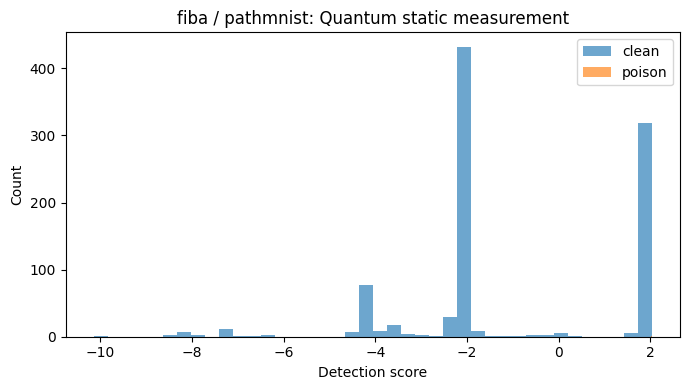

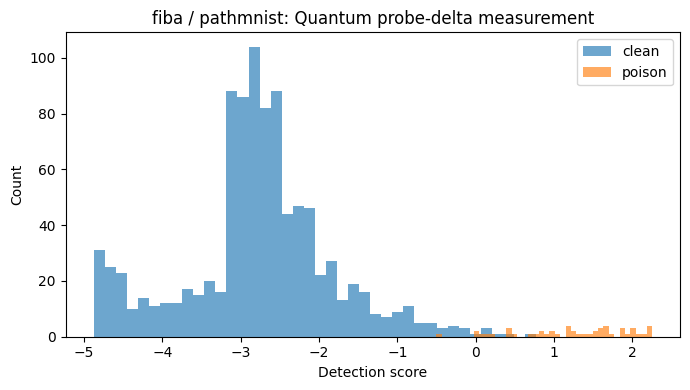

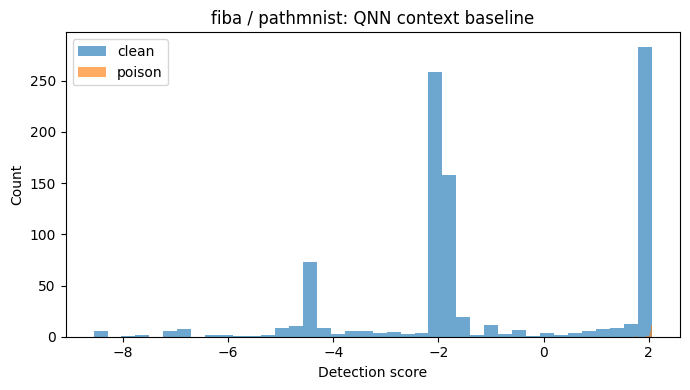

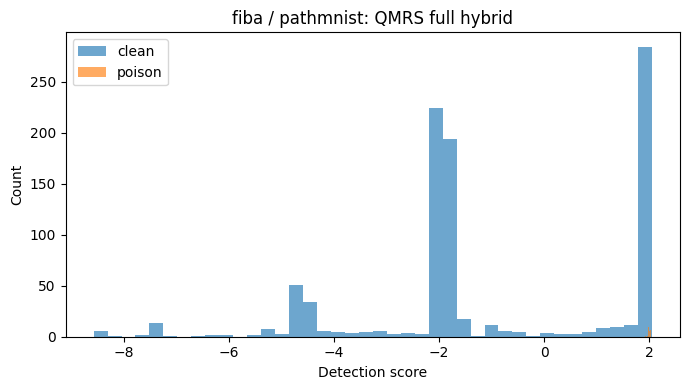

# Claim decision — fiba / pathmnist

Final claim category: **Weak**

Reason: Quantum features provide useful signal, but not primary detection power.

Safe wording: Do not claim quantum-measurement dominance unless the feature ablation table proves it. Use the table-generated category above.



In [6]:
# ============================================================
# PATCHED: Attack-success-first workflow, output control, ASR gate
# Scope: FIBA / PathMNIST only. No QTrojan. No Blend.
# ============================================================

# Keep runtime focused on QNN attack success first.
# Classical poisoned baseline is optional and can be re-enabled after ASR passes.
RUN_CLASSICAL_POISONED_BASELINE = False

# Hard scope guards
assert ATTACK_NAME == "fiba"
assert DATASET_NAME == "pathmnist"
assert RUN_PATHMNIST_FIBA is True
assert RUN_DERMAMNIST_BLEND is False


def apply_fiba_lowfreq_batch(X, trigger, alpha=0.25, radius=10):
    """
    FIBA-style low-frequency amplitude injection.
    X, trigger: tensors [N, C, H, W], values in [0,1].
    Keeps source phase and injects trigger amplitude in the low-frequency region.
    Returns tensor on the same device and dtype as X.
    """
    if not torch.is_tensor(X) or not torch.is_tensor(trigger):
        raise TypeError("X and trigger must be torch.Tensor objects.")
    if X.ndim != 4:
        raise ValueError(f"X must be [N,C,H,W], got shape={tuple(X.shape)}")
    if trigger.ndim not in (3, 4):
        raise ValueError(f"trigger must be [C,H,W] or [N,C,H,W], got shape={tuple(trigger.shape)}")
    if float(X.min()) < -1e-6 or float(X.max()) > 1.0 + 1e-6:
        raise ValueError("FIBA expects X values in [0,1].")
    if float(trigger.min()) < -1e-6 or float(trigger.max()) > 1.0 + 1e-6:
        raise ValueError("FIBA expects trigger values in [0,1].")

    device = X.device
    dtype = X.dtype

    X_np = X.detach().cpu().numpy().astype(np.float32)
    trig_np = trigger.detach().cpu().numpy().astype(np.float32)

    if trig_np.ndim == 3:
        trig_np = trig_np[None]
    if trig_np.shape[0] == 1:
        trig_np = np.repeat(trig_np, X_np.shape[0], axis=0)

    if trig_np.shape[0] != X_np.shape[0]:
        raise ValueError(f"trigger batch must be 1 or N; got trigger N={trig_np.shape[0]}, X N={X_np.shape[0]}")
    if trig_np.shape[1:] != X_np.shape[1:]:
        raise ValueError(f"trigger shape {trig_np.shape[1:]} must match X shape {X_np.shape[1:]}")

    out = np.zeros_like(X_np, dtype=np.float32)

    for i in range(X_np.shape[0]):
        for c in range(X_np.shape[1]):
            Xf = np.fft.fft2(X_np[i, c])
            Tf = np.fft.fft2(trig_np[i, c])

            X_amp, X_phase = np.abs(Xf), np.angle(Xf)
            T_amp = np.abs(Tf)

            X_amp_shift = np.fft.fftshift(X_amp)
            T_amp_shift = np.fft.fftshift(T_amp)

            H, W = X_amp.shape
            cy, cx = H // 2, W // 2
            yy, xx = np.ogrid[:H, :W]
            mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= radius ** 2

            mixed_amp_shift = X_amp_shift.copy()
            mixed_amp_shift[mask] = (
                (1.0 - alpha) * X_amp_shift[mask] + alpha * T_amp_shift[mask]
            )

            mixed_amp = np.fft.ifftshift(mixed_amp_shift)
            X_new = mixed_amp * np.exp(1j * X_phase)
            out[i, c] = np.real(np.fft.ifft2(X_new))

    return torch.tensor(np.clip(out, 0, 1), dtype=dtype, device=device)


def make_target_mean_trigger(X_train, y_train, target_class, size=96):
    """
    Build target-class mean trigger from training/validation data only.
    If X_train is not already at model resolution, resize before averaging.
    """
    idx = torch.where(y_train == target_class)[0]
    if len(idx) == 0:
        raise ValueError(f"No samples found for target_class={target_class}")

    X_t = X_train[idx].float()
    if X_t.shape[-2:] != (size, size):
        X_t = F.interpolate(X_t, size=(size, size), mode="bilinear", align_corners=False)

    trigger = X_t.mean(dim=0, keepdim=True)
    return trigger.clamp(0, 1)


def _img_chw_to_hwc(x):
    x = x.detach().cpu().float().clamp(0, 1)
    if x.ndim == 4:
        x = x[0]
    arr = x.permute(1, 2, 0).numpy()
    if arr.shape[-1] == 1:
        arr = arr[..., 0]
    return arr


def save_fiba_visual_outputs(bundle, final_art, final_cfg, seed):
    """
    Save required attack-inspection figures:
    - fiba_trigger_preview.png
    - fiba_clean_vs_triggered_examples.png
    """
    os.makedirs(final_cfg.out_dir, exist_ok=True)

    trigger = final_art["trigger"].detach().cpu().clamp(0, 1)
    plt.figure(figsize=(3, 3))
    plt.imshow(_img_chw_to_hwc(trigger))
    plt.axis("off")
    plt.title(f"FIBA target-mean trigger\nTarget={final_cfg.target_class}")
    plt.tight_layout()
    plt.savefig(os.path.join(final_cfg.out_dir, "fiba_trigger_preview.png"), dpi=150, bbox_inches="tight")
    plt.close()

    y_train_np = bundle["y_train"].cpu().numpy()
    src_idx = np.where(y_train_np == final_cfg.source_class)[0]
    if len(src_idx) == 0:
        raise ValueError(f"No source-class examples found for source_class={final_cfg.source_class}")
    rng = np.random.default_rng(seed)
    chosen = np.sort(rng.choice(src_idx, size=min(4, len(src_idx)), replace=False))

    X_clean = resize_tensor_images(bundle["X_train"][chosen], final_cfg.model_image_size)
    X_triggered = apply_fiba_lowfreq_batch(
        X_clean,
        final_art["trigger"],
        alpha=final_cfg.fiba_strength,
        radius=final_cfg.fiba_low_freq_radius,
    )

    n = len(chosen)
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    if n == 1:
        axes = np.array(axes).reshape(2, 1)
    for j in range(n):
        axes[0, j].imshow(_img_chw_to_hwc(X_clean[j]))
        axes[0, j].set_title("Clean source")
        axes[0, j].axis("off")
        axes[1, j].imshow(_img_chw_to_hwc(X_triggered[j]))
        axes[1, j].set_title("FIBA triggered")
        axes[1, j].axis("off")
    plt.suptitle(f"FIBA examples: {final_cfg.source_class} → {final_cfg.target_class}, alpha={final_cfg.fiba_strength}")
    plt.tight_layout()
    plt.savefig(os.path.join(final_cfg.out_dir, "fiba_clean_vs_triggered_examples.png"), dpi=150, bbox_inches="tight")
    plt.close()


def save_fiba_config_used(final_cfg, bundle, pilot_df):
    config_path = os.path.join(final_cfg.out_dir, "fiba_config_used.json")
    payload = asdict(final_cfg)
    payload.update({
        "ATTACK_NAME": ATTACK_NAME,
        "DATASET_NAME": DATASET_NAME,
        "RUN_PATHMNIST_FIBA": RUN_PATHMNIST_FIBA,
        "RUN_DERMAMNIST_BLEND": RUN_DERMAMNIST_BLEND,
        "candidate_pairs": CANDIDATE_PAIRS_FIBA,
        "class_map": {str(k): str(v) for k, v in bundle.get("class_map", {}).items()},
        "pair_selection_rows": len(pilot_df) if pilot_df is not None else 0,
    })
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    return config_path


def save_fiba_run_log(final_cfg, attack_success_df, gate_passed, reason):
    row = attack_success_df.iloc[0].to_dict()
    log = f"""# FIBA / PathMNIST Run Log

## Scope
- Attack: {ATTACK_NAME}
- Dataset: {DATASET_NAME}
- Model: Hybrid classical-quantum QNN
- Source class: {row.get("Source")}
- Target class: {row.get("Target")}

## Attack configuration
- FIBA strength alpha: {row.get("FIBA Strength")}
- Poison rate: {row.get("Poison Rate")}
- Low-frequency radius: {row.get("Low-frequency Radius")}
- Model image size: {final_cfg.model_image_size}

## Attack-success validation
- Clean accuracy: {row.get("Clean Accuracy")}
- FIBA ASR: {row.get("FIBA ASR")}
- Clean accuracy gate: {final_cfg.clean_acc_min}
- ASR gate: {final_cfg.asr_min}
- Gate passed: {gate_passed}

## Decision
{reason}

## Rule
Detection/QSentry/QMRS outputs are valid only after the FIBA ASR and clean-accuracy gates pass.
"""
    path = os.path.join(final_cfg.out_dir, "fiba_run_log.md")
    with open(path, "w", encoding="utf-8") as f:
        f.write(log)
    return path


def choose_pair_and_strength(bundle, base_cfg, seed):
    """
    Validation-only pair/strength selection.
    Selection uses ONLY validation clean accuracy and validation ASR.
    It does not use detection AUPRC or test data.
    """
    values = list(base_cfg.fiba_strength_values)
    pairs = list(CANDIDATE_PAIRS_FIBA)
    rows = []

    print("Validation-only FIBA pair/strength selection — ASR/CA only, no detection metrics.")
    for source, target in pairs:
        for value in values:
            local_cfg = clone_cfg(base_cfg, source_class=source, target_class=target, fiba_strength=value)
            try:
                art = train_poisoned_model(
                    bundle,
                    local_cfg,
                    seed,
                    max_train_n=local_cfg.pilot_max_train_n,
                    epochs_override=local_cfg.pilot_epochs,
                    eval_split="val",
                    train_classical_baseline=False,
                )
                ca = float(art["qnn_ca"]["accuracy"])
                asr = float(art["qnn_asr"]["accuracy"])
                gate = bool(asr >= local_cfg.asr_min and ca >= local_cfg.clean_acc_min)
                rows.append({
                    "Attack": ATTACK_NAME,
                    "Dataset": DATASET_NAME,
                    "Source": source,
                    "Target": target,
                    "FIBA Strength": value,
                    "Poison Rate": local_cfg.fiba_poison_rate,
                    "Low-frequency Radius": local_cfg.fiba_low_freq_radius,
                    "Eval Split": "validation",
                    "Val/Pilot Clean Accuracy": ca,
                    "Val/Pilot FIBA ASR": asr,
                    "Clean Accuracy Gate": local_cfg.clean_acc_min,
                    "ASR Gate": local_cfg.asr_min,
                    "Gate Passed?": gate,
                    "error": "",
                })
            except Exception as exc:
                rows.append({
                    "Attack": ATTACK_NAME,
                    "Dataset": DATASET_NAME,
                    "Source": source,
                    "Target": target,
                    "FIBA Strength": value,
                    "Poison Rate": local_cfg.fiba_poison_rate,
                    "Low-frequency Radius": local_cfg.fiba_low_freq_radius,
                    "Eval Split": "validation",
                    "Val/Pilot Clean Accuracy": np.nan,
                    "Val/Pilot FIBA ASR": np.nan,
                    "Clean Accuracy Gate": local_cfg.clean_acc_min,
                    "ASR Gate": local_cfg.asr_min,
                    "Gate Passed?": False,
                    "error": str(exc),
                })
                NEEDS_VERIFICATION.append(f"needs verification: pilot failed for {source}->{target}, alpha={value}: {exc}")

    pilot_df = pd.DataFrame(rows)
    os.makedirs(base_cfg.out_dir, exist_ok=True)
    pilot_path = os.path.join(base_cfg.out_dir, "fiba_source_target_selection.csv")
    pilot_df.to_csv(pilot_path, index=False)
    display(pilot_df)

    valid = pilot_df[pilot_df["Gate Passed?"] == True].copy()
    if valid.empty:
        raise RuntimeError(
            "No valid FIBA source-target pair reached the ASR/CA gate. "
            "Increase strength, poison rate, training epochs, or check FIBA implementation."
        )

    # Correct selection rule: highest validation ASR, then highest validation clean accuracy, then lower alpha for stealth.
    valid = valid.sort_values(
        ["Val/Pilot FIBA ASR", "Val/Pilot Clean Accuracy", "FIBA Strength"],
        ascending=[False, False, True],
        na_position="last",
    )
    best = valid.iloc[0]
    print("Selected validation setting:", best.to_dict())
    return int(best["Source"]), int(best["Target"]), float(best["FIBA Strength"]), pilot_df


def build_feature_spaces(final_art, X_val_pool, X_test_pool, classical_model, local_cfg):
    q_val, qctx_val, _ = extract_qnn_features(final_art["qnn"], X_val_pool, local_cfg, DEVICE)
    q_test, qctx_test, _ = extract_qnn_features(final_art["qnn"], X_test_pool, local_cfg, DEVICE)

    raw_val = X_val_pool.reshape(len(X_val_pool), -1).numpy().astype(np.float32)
    raw_test = X_test_pool.reshape(len(X_test_pool), -1).numpy().astype(np.float32)

    classical_ctx_val = extract_classical_context(classical_model, X_val_pool, local_cfg, DEVICE)
    classical_ctx_test = extract_classical_context(classical_model, X_test_pool, local_cfg, DEVICE)

    qprobe_val = extract_quantum_probe_features(final_art["qnn"], X_val_pool, local_cfg, DEVICE)
    qprobe_test = extract_quantum_probe_features(final_art["qnn"], X_test_pool, local_cfg, DEVICE)

    qstat_val = quantum_readout_statistics(q_val)
    qstat_test = quantum_readout_statistics(q_test)

    qmrs_full_val = extract_qmrs_full_hybrid_features(final_art["qnn"], X_val_pool, local_cfg, DEVICE)
    qmrs_full_test = extract_qmrs_full_hybrid_features(final_art["qnn"], X_test_pool, local_cfg, DEVICE)

    balanced_val, balanced_test = make_block_weighted_hybrid(
        {"quantum_probe": qprobe_val, "qnn_context": qctx_val},
        {"quantum_probe": qprobe_test, "qnn_context": qctx_test},
        weights={"quantum_probe": 1.0, "qnn_context": 0.5},
    )

    feature_spaces = {
        "Raw pixel baseline": (raw_val, raw_test),
        "QNN context baseline": (qctx_val, qctx_test),
        "Quantum static measurement": (q_val, q_test),
        "Quantum probe-delta measurement": (qprobe_val, qprobe_test),
        "Quantum readout statistics": (qstat_val, qstat_test),
        "Balanced quantum+context hybrid": (balanced_val, balanced_test),
        "QMRS full hybrid": (qmrs_full_val, qmrs_full_test),
    }

    if classical_ctx_val is None:
        NEEDS_VERIFICATION.append("needs verification: Classical context baseline unavailable because classical poisoned baseline was not trained.")
    else:
        feature_spaces["Classical context baseline"] = (classical_ctx_val, classical_ctx_test)

    return feature_spaces


def run_notebook():
    bundle = load_dataset_bundle(DATASET_NAME)

    if RUN_PAIR_SELECTION:
        source, target, selected_value, pilot_df = choose_pair_and_strength(bundle, cfg, cfg.primary_seed)
    else:
        source, target = (8, 5)
        selected_value = cfg.fiba_strength
        pilot_df = pd.DataFrame([{
            "Status": "pair selection disabled; using configured pair",
            "Source": source,
            "Target": target,
            "FIBA Strength": selected_value,
        }])
        pilot_df.to_csv(os.path.join(cfg.out_dir, "fiba_source_target_selection.csv"), index=False)

    final_cfg = clone_cfg(cfg, source_class=source, target_class=target, fiba_strength=selected_value)

    final_art = train_poisoned_model(
        bundle,
        final_cfg,
        cfg.primary_seed,
        max_train_n=final_cfg.max_train_n,
        epochs_override=final_cfg.clean_epochs,
        eval_split="test",
        train_classical_baseline=RUN_CLASSICAL_POISONED_BASELINE,
    )

    qnn_ca = float(final_art["qnn_ca"]["accuracy"])
    qnn_asr = float(final_art["qnn_asr"]["accuracy"])

    classical_ca = float(final_art["classical_ca"]["accuracy"]) if final_art["classical_ca"] else np.nan
    classical_asr = float(final_art["classical_asr"]["accuracy"]) if final_art["classical_asr"] else np.nan

    ca_ok = bool(qnn_ca >= final_cfg.clean_acc_min)
    asr_ok = bool(qnn_asr >= final_cfg.asr_min)
    gate_passed = bool(ca_ok and asr_ok)

    attack_success_df = pd.DataFrame([{
        "Attack": ATTACK_NAME,
        "Dataset": DATASET_NAME,
        "Source": source,
        "Target": target,
        "Source→Target": f"{source}->{target}",
        "FIBA Strength": selected_value,
        "Poison Rate": final_cfg.fiba_poison_rate,
        "Low-frequency Radius": final_cfg.fiba_low_freq_radius,
        "Clean Accuracy": qnn_ca,
        "FIBA ASR": qnn_asr,
        "Clean Accuracy Gate": final_cfg.clean_acc_min,
        "ASR Gate": final_cfg.asr_min,
        "Clean Accuracy Passed?": ca_ok,
        "ASR Passed?": asr_ok,
        "Gate Passed?": gate_passed,
        "Classical Poisoned CA": classical_ca,
        "Classical Poisoned ASR": classical_asr,
        "Status": "passed_attack_gate" if gate_passed else "blocked_by_weak_attack",
    }])

    os.makedirs(final_cfg.out_dir, exist_ok=True)
    attack_success_df.to_csv(os.path.join(final_cfg.out_dir, "fiba_attack_success.csv"), index=False)
    save_fiba_config_used(final_cfg, bundle, pilot_df)
    save_fiba_visual_outputs(bundle, final_art, final_cfg, cfg.primary_seed)

    reason = (
        "FIBA attack passed both ASR and clean-accuracy gates. Detection/QSentry may run next."
        if gate_passed else
        "FIBA attack did not pass the ASR/clean-accuracy gate. Detection/QSentry/QMRS must not be run."
    )
    save_fiba_run_log(final_cfg, attack_success_df, gate_passed, reason)

    display(attack_success_df)

    if not gate_passed:
        raise RuntimeError(
            f"FIBA blocked. Clean Accuracy={qnn_ca:.4f} "
            f"(gate {final_cfg.clean_acc_min:.2f}), "
            f"FIBA ASR={qnn_asr:.4f} (gate {final_cfg.asr_min:.2f}). "
            "Do not run detection yet. Fix attack implantation first."
        )

    # Detection starts only after the attack-success gate passes.
    X_val_pool, y_val_poison, val_groups, val_summary = build_fiba_detection_pool(
        bundle["X_val"], bundle["y_val"], final_art["trigger"], final_cfg, cfg.primary_seed
    )
    X_test_pool, y_test_poison, test_groups, test_summary = build_fiba_detection_pool(
        bundle["X_test"], bundle["y_test"], final_art["trigger"], final_cfg, cfg.primary_seed + 17
    )

    feature_spaces = build_feature_spaces(final_art, X_val_pool, X_test_pool, final_art["classical"], final_cfg)

    det_rows, k_rows, score_by_feature = [], [], {}
    expected_poison_count = int(np.asarray(y_test_poison).sum())

    required_features = [
        "Raw pixel baseline",
        "Classical context baseline",
        "QNN context baseline",
        "Quantum static measurement",
        "Quantum probe-delta measurement",
        "Quantum readout statistics",
        "Balanced quantum+context hybrid",
        "QMRS full hybrid",
    ]

    for feature_name in required_features:
        if feature_name not in feature_spaces:
            det_rows.append({
                "Attack": ATTACK_NAME, "Dataset": DATASET_NAME,
                "Feature Space": feature_name, "K": np.nan,
                "Threshold Method": "needs implementation",
                "F1": np.nan, "Precision": np.nan, "Recall": np.nan,
                "AUPRC": np.nan, "AUROC": np.nan,
            })
            continue

        fv, ft = feature_spaces[feature_name]
        row, val_df, test_scores = select_k_and_evaluate(
            feature_name, fv, y_val_poison, ft, y_test_poison, final_cfg, expected_poison_count
        )
        row.update({"Attack": ATTACK_NAME, "Dataset": DATASET_NAME})
        det_rows.append(row)
        val_df["Attack"] = ATTACK_NAME
        val_df["Dataset"] = DATASET_NAME
        k_rows.append(val_df)
        score_by_feature[feature_name] = test_scores

    detection_df = pd.DataFrame(det_rows)[[
        "Attack", "Dataset", "Feature Space", "K", "Threshold Method",
        "F1", "Precision", "Recall", "AUPRC", "AUROC"
    ]]
    k_selection_df = pd.concat(k_rows, ignore_index=True) if k_rows else pd.DataFrame()

    detection_df.to_csv(os.path.join(final_cfg.out_dir, "fiba_feature_ablation.csv"), index=False)
    k_selection_df.to_csv(os.path.join(final_cfg.out_dir, "fiba_k_selection.csv"), index=False)

    display(detection_df.sort_values("AUPRC", ascending=False, na_position="last"))

    plot_map = {
        "Quantum static measurement": "fiba_score_distribution_quantum_static.png",
        "Quantum probe-delta measurement": "fiba_score_distribution_quantum_probe_delta.png",
        "QNN context baseline": "fiba_score_distribution_qnn_context.png",
        "Classical context baseline": "fiba_score_distribution_classical_context.png",
        "QMRS full hybrid": "fiba_score_distribution_qmrs_full.png",
    }
    for fname, png in plot_map.items():
        if fname in score_by_feature:
            plot_detection_score_distribution(
                score_by_feature[fname],
                y_test_poison,
                f"{ATTACK_NAME} / {DATASET_NAME}: {fname}",
                os.path.join(final_cfg.out_dir, png),
            )

    save_claim_decision(
        detection_df,
        ATTACK_NAME,
        DATASET_NAME,
        os.path.join(final_cfg.out_dir, "fiba_claim_decision.md"),
    )

    report = {
        "attack": ATTACK_NAME,
        "dataset": DATASET_NAME,
        "needs_verification": sorted(set(NEEDS_VERIFICATION)),
        "planned_pending": PLANNED_PENDING,
        "outputs": {
            "attack_success": os.path.join(final_cfg.out_dir, "fiba_attack_success.csv"),
            "config_used": os.path.join(final_cfg.out_dir, "fiba_config_used.json"),
            "source_target_selection": os.path.join(final_cfg.out_dir, "fiba_source_target_selection.csv"),
            "trigger_preview": os.path.join(final_cfg.out_dir, "fiba_trigger_preview.png"),
            "clean_vs_triggered_examples": os.path.join(final_cfg.out_dir, "fiba_clean_vs_triggered_examples.png"),
            "run_log": os.path.join(final_cfg.out_dir, "fiba_run_log.md"),
            "feature_ablation": os.path.join(final_cfg.out_dir, "fiba_feature_ablation.csv"),
            "k_selection": os.path.join(final_cfg.out_dir, "fiba_k_selection.csv"),
            "claim_decision": os.path.join(final_cfg.out_dir, "fiba_claim_decision.md"),
        },
    }
    with open(os.path.join(final_cfg.out_dir, "fiba_run_report.json"), "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)

    return {"attack_success": attack_success_df, "detection": detection_df, "k_selection": k_selection_df}




# ============================================================
# RESCUE PATCH v2: stronger validation-only FIBA attack search
# Why: first pilot showed high ASR on some pairs but weak CA due to tiny
# 2-epoch/1500-sample pilot. This patch does NOT lower the ASR gate.
# It increases attack-training budget and selects by validation ASR + CA only.
# ============================================================

# Rescue settings after the first failed validation pilot.
# These are proposed fix settings and require experiment output verification.
cfg.pilot_epochs = max(int(cfg.pilot_epochs), 5)
cfg.pilot_max_train_n = max(int(cfg.pilot_max_train_n), 3500)
cfg.clean_epochs = max(int(cfg.clean_epochs), 10)
cfg.max_train_n = max(int(cfg.max_train_n), 8000)
cfg.lr_base = max(float(cfg.lr_base), 7e-4)
cfg.label_smoothing = min(float(cfg.label_smoothing), 0.03)

assert cfg.asr_min == 0.80, "Do not lower the FIBA ASR gate."
assert cfg.clean_acc_min >= 0.50, "Do not weaken the clean-accuracy gate without explicit justification."


def _col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def _build_rescue_grid_from_previous_csv(base_cfg):
    """
    Build a small rescue grid using validation-only evidence from the failed pilot CSV.
    This avoids tuning on test data and avoids running a huge blind grid.
    """
    path = os.path.join(base_cfg.out_dir, "fiba_source_target_selection.csv")
    rows = []

    if os.path.exists(path):
        prev = pd.read_csv(path)
        src_c = _col(prev, ["Source"])
        tgt_c = _col(prev, ["Target"])
        alpha_c = _col(prev, ["FIBA Strength", "Strength/Alpha"])
        ca_c = _col(prev, ["Val/Pilot Clean Accuracy", "Val/Pilot CA"])
        asr_c = _col(prev, ["Val/Pilot FIBA ASR", "Val/Pilot ASR"])
        if all(c is not None for c in [src_c, tgt_c, alpha_c, ca_c, asr_c]):
            tmp = prev[[src_c, tgt_c, alpha_c, ca_c, asr_c]].copy()
            tmp.columns = ["Source", "Target", "Alpha", "CA", "ASR"]
            tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna()
            # Keep configs that showed either target attraction or meaningful clean learning.
            tmp = tmp[(tmp["ASR"] >= 0.20) | (tmp["CA"] >= 0.45)].copy()
            if len(tmp):
                tmp["rescue_score"] = 0.70 * tmp["ASR"].astype(float) + 0.30 * tmp["CA"].astype(float)
                tmp = tmp.sort_values(["rescue_score", "ASR", "CA"], ascending=False).head(4)
                for _, r in tmp.iterrows():
                    s, t, a = int(r["Source"]), int(r["Target"]), float(r["Alpha"])
                    for alpha in sorted(set([a, min(0.45, a + 0.05), 0.35, 0.30]), reverse=True):
                        for poison_rate in [0.20, 0.25]:
                            for radius in [12, 10]:
                                rows.append((s, t, float(alpha), float(poison_rate), int(radius)))

    if not rows:
        # Fallback if no previous CSV exists. Still validation-only, but focused.
        for s, t in CANDIDATE_PAIRS_FIBA:
            for alpha in [0.45, 0.40, 0.35, 0.30]:
                rows.append((int(s), int(t), float(alpha), 0.20, 12))

    # Deduplicate and cap runtime.
    dedup = []
    seen = set()
    for item in rows:
        if item not in seen:
            seen.add(item)
            dedup.append(item)
    return dedup[:18]


def choose_pair_and_strength(bundle, base_cfg, seed):
    """
    Rescue validation-only source-target/hyperparameter selection.
    Selection uses validation clean accuracy and validation ASR only.
    No detection metrics. No test-set tuning.
    """
    grid = _build_rescue_grid_from_previous_csv(base_cfg)
    rows = []

    print("Rescue FIBA validation search — ASR/CA only, no AUPRC, no test tuning.")
    print(f"Trials: {len(grid)} | pilot_epochs={base_cfg.pilot_epochs} | pilot_max_train_n={base_cfg.pilot_max_train_n}")

    for source, target, alpha, poison_rate, radius in grid:
        local_cfg = clone_cfg(
            base_cfg,
            source_class=int(source),
            target_class=int(target),
            fiba_strength=float(alpha),
            fiba_poison_rate=float(poison_rate),
            fiba_low_freq_radius=int(radius),
            label_smoothing=min(float(base_cfg.label_smoothing), 0.03),
            lr_base=max(float(base_cfg.lr_base), 7e-4),
        )
        try:
            art = train_poisoned_model(
                bundle,
                local_cfg,
                seed,
                max_train_n=local_cfg.pilot_max_train_n,
                epochs_override=local_cfg.pilot_epochs,
                eval_split="val",
                train_classical_baseline=False,
            )
            ca = float(art["qnn_ca"]["accuracy"])
            asr = float(art["qnn_asr"]["accuracy"])
            gate = bool(asr >= local_cfg.asr_min and ca >= local_cfg.clean_acc_min)
            err = ""
        except Exception as exc:
            ca, asr, gate, err = np.nan, np.nan, False, str(exc)
            NEEDS_VERIFICATION.append(
                f"needs verification: rescue pilot failed for {source}->{target}, "
                f"alpha={alpha}, poison_rate={poison_rate}, radius={radius}: {exc}"
            )

        rows.append({
            "Attack": ATTACK_NAME,
            "Dataset": DATASET_NAME,
            "Source": int(source),
            "Target": int(target),
            "FIBA Strength": float(alpha),
            "Poison Rate": float(poison_rate),
            "Low-frequency Radius": int(radius),
            "Eval Split": "validation",
            "Pilot Epochs": int(local_cfg.pilot_epochs),
            "Pilot Max Train N": int(local_cfg.pilot_max_train_n),
            "Label Smoothing": float(local_cfg.label_smoothing),
            "Learning Rate": float(local_cfg.lr_base),
            "Val/Pilot Clean Accuracy": ca,
            "Val/Pilot FIBA ASR": asr,
            "Clean Accuracy Gate": float(local_cfg.clean_acc_min),
            "ASR Gate": float(local_cfg.asr_min),
            "Gate Passed?": gate,
            "error": err,
        })

    pilot_df = pd.DataFrame(rows)
    os.makedirs(base_cfg.out_dir, exist_ok=True)
    pilot_df.to_csv(os.path.join(base_cfg.out_dir, "fiba_source_target_selection.csv"), index=False)
    display(pilot_df.sort_values(["Gate Passed?", "Val/Pilot FIBA ASR", "Val/Pilot Clean Accuracy"], ascending=[False, False, False]))

    valid = pilot_df[pilot_df["Gate Passed?"] == True].copy()
    if valid.empty:
        top = pilot_df.sort_values(["Val/Pilot FIBA ASR", "Val/Pilot Clean Accuracy"], ascending=False).head(6)
        print("Top failed validation settings:")
        display(top)
        raise RuntimeError(
            "No valid FIBA source-target/strength/poison/radius setting reached the ASR/CA gate after rescue search. "
            "Do not run detection. Next fix: increase clean_epochs to 12-15, max_train_n to 12000, "
            "or inspect whether target-class amplitude trigger is too weak for PathMNIST."
        )

    # Primary rule: pass gate, then highest ASR, highest CA, lower alpha, lower poison rate, lower radius for stealth.
    valid = valid.sort_values(
        ["Val/Pilot FIBA ASR", "Val/Pilot Clean Accuracy", "FIBA Strength", "Poison Rate", "Low-frequency Radius"],
        ascending=[False, False, True, True, True],
        na_position="last",
    )
    best = valid.iloc[0]

    # Mutate base_cfg so the existing run_notebook() final_cfg inherits the selected poison/radius/training settings.
    base_cfg.fiba_poison_rate = float(best["Poison Rate"])
    base_cfg.fiba_low_freq_radius = int(best["Low-frequency Radius"])
    base_cfg.label_smoothing = float(best["Label Smoothing"])
    base_cfg.lr_base = float(best["Learning Rate"])
    base_cfg.clean_epochs = max(int(base_cfg.clean_epochs), 10)
    base_cfg.max_train_n = max(int(base_cfg.max_train_n), 8000)

    print("Selected validation setting:")
    print(best.to_dict())
    return int(best["Source"]), int(best["Target"]), float(best["FIBA Strength"]), pilot_df


results = run_notebook()


## Research-grade FIBA/QSentry/QXAI patch cell

This cell adds validation-only FIBA search, fair classical context baseline support, FIBA-specific quantum probe features, QXAI explanation outputs, QSentry comparison notes, and honest claim-decision logic. It does not touch QTrojan or Blend.

In [7]:
# ============================================================
# QMedShield / QSentry FIBA PathMNIST research-grade patch
# Scope: FIBA / PathMNIST only. No QTrojan. No Blend.
# Paste this after the model/FIBA helper cells and before final execution,
# or run after the previous notebook execution to produce missing audit outputs.
# ============================================================

import os, json, math
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, roc_auc_score

# Force the missing fair baseline. This does not alter the QNN architecture.
RUN_CLASSICAL_POISONED_BASELINE = True


def apply_fiba_lowfreq_batch(X, trigger, alpha=0.25, radius=10):
    """
    FIBA-style low-frequency amplitude injection.
    X, trigger: tensors [N,C,H,W], values in [0,1].
    Keeps source phase and injects trigger amplitude only inside a centered low-frequency mask.
    Returns same device and dtype as X.
    """
    if not torch.is_tensor(X) or not torch.is_tensor(trigger):
        raise TypeError("X and trigger must be torch.Tensor objects.")
    if X.ndim != 4:
        raise ValueError(f"X must be [N,C,H,W], got {tuple(X.shape)}")
    if trigger.ndim not in (3, 4):
        raise ValueError(f"trigger must be [C,H,W] or [N,C,H,W], got {tuple(trigger.shape)}")
    if X.numel() == 0:
        raise ValueError("X is empty.")
    if not (0.0 <= float(X.min()) and float(X.max()) <= 1.0 + 1e-6):
        raise ValueError("FIBA expects X values in [0,1].")
    if not (0.0 <= float(trigger.min()) and float(trigger.max()) <= 1.0 + 1e-6):
        raise ValueError("FIBA expects trigger values in [0,1].")

    device, dtype = X.device, X.dtype
    X_np = X.detach().cpu().numpy().astype(np.float32)
    T_np = trigger.detach().cpu().numpy().astype(np.float32)

    if T_np.ndim == 3:
        T_np = T_np[None]
    if T_np.shape[0] == 1:
        T_np = np.repeat(T_np, X_np.shape[0], axis=0)
    if T_np.shape[0] != X_np.shape[0]:
        raise ValueError(f"Trigger batch must be 1 or N. trigger={T_np.shape[0]}, X={X_np.shape[0]}")
    if T_np.shape[1:] != X_np.shape[1:]:
        raise ValueError(f"Trigger shape {T_np.shape[1:]} must match X shape {X_np.shape[1:]}")

    out = np.empty_like(X_np, dtype=np.float32)
    for i in range(X_np.shape[0]):
        for c in range(X_np.shape[1]):
            Xf = np.fft.fft2(X_np[i, c])
            Tf = np.fft.fft2(T_np[i, c])

            X_amp = np.abs(Xf)
            X_phase = np.angle(Xf)
            T_amp = np.abs(Tf)

            X_amp_shift = np.fft.fftshift(X_amp)
            T_amp_shift = np.fft.fftshift(T_amp)

            H, W = X_amp_shift.shape
            cy, cx = H // 2, W // 2
            yy, xx = np.ogrid[:H, :W]
            mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= int(radius) ** 2

            A_mix_shift = X_amp_shift.copy()
            A_mix_shift[mask] = (1.0 - float(alpha)) * X_amp_shift[mask] + float(alpha) * T_amp_shift[mask]
            A_mix = np.fft.ifftshift(A_mix_shift)
            out[i, c] = np.real(np.fft.ifft2(A_mix * np.exp(1j * X_phase)))

    return torch.tensor(np.clip(out, 0.0, 1.0), dtype=dtype, device=device)


def make_target_mean_trigger(X_train, y_train, target_class, size=96):
    """Build a target-class mean trigger from training/validation tensors only, never from test."""
    idx = torch.where(y_train == int(target_class))[0]
    if len(idx) == 0:
        raise ValueError(f"No samples found for target_class={target_class}")
    X_t = X_train[idx].float()
    if X_t.shape[-2:] != (int(size), int(size)):
        X_t = F.interpolate(X_t, size=(int(size), int(size)), mode="bilinear", align_corners=False)
    return X_t.mean(dim=0, keepdim=True).clamp(0, 1)


def run_fiba_validation_search(bundle, base_cfg, seed=42, candidate_pairs=None,
                               strength_values=(0.45, 0.35, 0.25, 0.18, 0.12),
                               poison_rates=(0.05, 0.10, 0.15, 0.20),
                               radius_values=(6, 8, 10, 12, 14),
                               stage1_epochs=5, stage2_epochs=6,
                               top_pair_count=4, out_name="fiba_validation_search.csv"):
    """
    Validation-only staged search. It does not use test data and does not rank by detection metrics.
    Stage 1: screen pairs using a strong but fixed setting.
    Stage 2: sweep alpha / poison_rate / radius only on top validation pairs.
    """
    if candidate_pairs is None:
        candidate_pairs = CANDIDATE_PAIRS_FIBA
    rows = []

    # Stage 1: pair screen.
    for source, target in candidate_pairs:
        local_cfg = clone_cfg(base_cfg,
            source_class=int(source), target_class=int(target),
            fiba_strength=0.45, fiba_poison_rate=0.20, fiba_low_freq_radius=12,
            pilot_epochs=int(stage1_epochs), pilot_max_train_n=max(int(base_cfg.pilot_max_train_n), 3500),
            label_smoothing=min(float(base_cfg.label_smoothing), 0.03), lr_base=max(float(base_cfg.lr_base), 7e-4),
        )
        try:
            art = train_poisoned_model(bundle, local_cfg, seed, max_train_n=local_cfg.pilot_max_train_n,
                                       epochs_override=local_cfg.pilot_epochs, eval_split="val",
                                       train_classical_baseline=False)
            ca, asr, err = float(art["qnn_ca"]["accuracy"]), float(art["qnn_asr"]["accuracy"]), ""
        except Exception as exc:
            ca, asr, err = np.nan, np.nan, str(exc)
        rows.append({"stage":"pair_screen", "Source":int(source), "Target":int(target),
                     "Alpha":0.45, "Poison Rate":0.20, "Radius":12,
                     "Val CA":ca, "Val ASR":asr, "Gate Passed?": bool(asr >= base_cfg.asr_min and ca >= base_cfg.clean_acc_min),
                     "error":err})

    screen_df = pd.DataFrame(rows)
    ranked_pairs = (screen_df.dropna(subset=["Val CA", "Val ASR"])
                    .sort_values(["Gate Passed?", "Val ASR", "Val CA"], ascending=[False, False, False])
                    [["Source", "Target"]].drop_duplicates().head(int(top_pair_count)))

    if ranked_pairs.empty:
        pd.DataFrame(rows).to_csv(os.path.join(base_cfg.out_dir, out_name), index=False)
        raise RuntimeError("Validation pair screen failed: no usable source-target pair. Do not run detection.")

    # Stage 2: controlled hyperparameter sweep on top pairs only.
    for _, pair in ranked_pairs.iterrows():
        source, target = int(pair["Source"]), int(pair["Target"])
        for alpha in strength_values:
            for rho in poison_rates:
                for radius in radius_values:
                    # Skip very weak combinations unless specifically desired.
                    if alpha <= 0.18 and rho <= 0.10 and radius <= 8:
                        continue
                    local_cfg = clone_cfg(base_cfg,
                        source_class=source, target_class=target,
                        fiba_strength=float(alpha), fiba_poison_rate=float(rho), fiba_low_freq_radius=int(radius),
                        pilot_epochs=int(stage2_epochs), pilot_max_train_n=max(int(base_cfg.pilot_max_train_n), 3500),
                        label_smoothing=min(float(base_cfg.label_smoothing), 0.03), lr_base=max(float(base_cfg.lr_base), 7e-4),
                    )
                    try:
                        art = train_poisoned_model(bundle, local_cfg, seed, max_train_n=local_cfg.pilot_max_train_n,
                                                   epochs_override=local_cfg.pilot_epochs, eval_split="val",
                                                   train_classical_baseline=False)
                        ca, asr, err = float(art["qnn_ca"]["accuracy"]), float(art["qnn_asr"]["accuracy"]), ""
                    except Exception as exc:
                        ca, asr, err = np.nan, np.nan, str(exc)
                    rows.append({"stage":"param_sweep", "Source":source, "Target":target,
                                 "Alpha":float(alpha), "Poison Rate":float(rho), "Radius":int(radius),
                                 "Val CA":ca, "Val ASR":asr,
                                 "Gate Passed?": bool(asr >= base_cfg.asr_min and ca >= base_cfg.clean_acc_min),
                                 "error":err})

    df = pd.DataFrame(rows)
    os.makedirs(base_cfg.out_dir, exist_ok=True)
    df.to_csv(os.path.join(base_cfg.out_dir, out_name), index=False)
    return df


def select_fiba_pair_and_params_validation_only(search_df, base_cfg):
    """Select only among validation-gated settings. No test metrics. No detection AUPRC."""
    valid = search_df[search_df["Gate Passed?"] == True].copy()
    if valid.empty:
        raise RuntimeError("No valid FIBA pair passed ASR/CA gate. Current FIBA branch is not ready for detection.")
    valid = valid.sort_values(["Val ASR", "Val CA", "Alpha", "Poison Rate", "Radius"],
                              ascending=[False, False, True, True, True])
    best = valid.iloc[0]
    selected_cfg = clone_cfg(base_cfg,
        source_class=int(best["Source"]), target_class=int(best["Target"]),
        fiba_strength=float(best["Alpha"]), fiba_poison_rate=float(best["Poison Rate"]),
        fiba_low_freq_radius=int(best["Radius"]),
        label_smoothing=min(float(base_cfg.label_smoothing), 0.03),
        lr_base=max(float(base_cfg.lr_base), 7e-4),
        clean_epochs=max(int(base_cfg.clean_epochs), 10),
        max_train_n=max(int(base_cfg.max_train_n), 8000),
    )
    return selected_cfg, best.to_dict()


def evaluate_fiba_attack_success(final_art, final_cfg, out_dir=None):
    """Save and enforce FIBA attack gate before any detector is allowed to run."""
    out_dir = out_dir or final_cfg.out_dir
    qnn_ca = float(final_art["qnn_ca"]["accuracy"])
    qnn_asr = float(final_art["qnn_asr"]["accuracy"])
    ca_ok = bool(qnn_ca >= final_cfg.clean_acc_min)
    asr_ok = bool(qnn_asr >= final_cfg.asr_min)
    row = {
        "Attack":"fiba", "Dataset":"pathmnist",
        "Source":int(final_cfg.source_class), "Target":int(final_cfg.target_class),
        "Source→Target":f"{final_cfg.source_class}->{final_cfg.target_class}",
        "FIBA Strength":float(final_cfg.fiba_strength), "Poison Rate":float(final_cfg.fiba_poison_rate),
        "Low-frequency Radius":int(final_cfg.fiba_low_freq_radius),
        "Clean Accuracy":qnn_ca, "FIBA ASR":qnn_asr,
        "Clean Accuracy Gate":float(final_cfg.clean_acc_min), "ASR Gate":float(final_cfg.asr_min),
        "Clean Accuracy Passed?":ca_ok, "ASR Passed?":asr_ok, "Gate Passed?":bool(ca_ok and asr_ok),
        "Status":"passed_attack_gate" if ca_ok and asr_ok else "blocked_by_weak_attack",
    }
    df = pd.DataFrame([row])
    os.makedirs(out_dir, exist_ok=True)
    df.to_csv(os.path.join(out_dir, "fiba_attack_success.csv"), index=False)
    if not row["Gate Passed?"]:
        raise RuntimeError(f"FIBA blocked. Clean Accuracy={qnn_ca:.4f}, FIBA ASR={qnn_asr:.4f}. Do not run detection.")
    return df


def build_fiba_qsentry_pool(bundle, trigger, final_cfg, split="test", seed=42):
    """Matched pool: clean source + clean target + FIBA-triggered source."""
    X = bundle[f"X_{split}"]
    y = bundle[f"y_{split}"]
    return build_fiba_detection_pool(X, y, trigger, final_cfg, seed)


def extract_frequency_probe_quantum_features(qnn_model, X_pool, final_cfg, device):
    """Quantum FIBA-specific probe: original measurement, low-frequency-suppressed measurement, and target-confidence delta."""
    q0, ctx0, probs0 = extract_qnn_features(qnn_model, X_pool, final_cfg, device)
    X_suppressed = low_frequency_suppress(X_pool, radius=final_cfg.fiba_low_freq_radius)
    q_s, _, probs_s = extract_qnn_features(qnn_model, X_suppressed, final_cfg, device)
    signed = q0 - q_s
    abs_delta = np.abs(signed)
    norm_delta = np.linalg.norm(signed, axis=1, keepdims=True)
    target_conf = probs0[:, final_cfg.target_class:final_cfg.target_class + 1]
    target_conf_delta = probs0[:, final_cfg.target_class:final_cfg.target_class + 1] - probs_s[:, final_cfg.target_class:final_cfg.target_class + 1]
    return np.concatenate([q0, q_s, signed, abs_delta, norm_delta, target_conf, target_conf_delta], axis=1)


def run_fiba_detection_ablation(final_art, X_val_pool, y_val_pool, X_test_pool, y_test_pool, final_cfg, out_dir=None):
    """Run matched detection ablation only after attack-success gate has already passed."""
    out_dir = out_dir or final_cfg.out_dir
    expected_poison_count = int(np.asarray(y_test_pool).sum())
    q_val, qctx_val, _ = extract_qnn_features(final_art["qnn"], X_val_pool, final_cfg, DEVICE)
    q_test, qctx_test, _ = extract_qnn_features(final_art["qnn"], X_test_pool, final_cfg, DEVICE)
    raw_val = X_val_pool.reshape(len(X_val_pool), -1).numpy().astype(np.float32)
    raw_test = X_test_pool.reshape(len(X_test_pool), -1).numpy().astype(np.float32)
    qprobe_val = extract_frequency_probe_quantum_features(final_art["qnn"], X_val_pool, final_cfg, DEVICE)
    qprobe_test = extract_frequency_probe_quantum_features(final_art["qnn"], X_test_pool, final_cfg, DEVICE)
    qstat_val = quantum_readout_statistics(q_val)
    qstat_test = quantum_readout_statistics(q_test)

    balanced_val, balanced_test = make_block_weighted_hybrid(
        {"quantum_probe": qprobe_val, "qnn_context": qctx_val},
        {"quantum_probe": qprobe_test, "qnn_context": qctx_test},
        weights={"quantum_probe": 1.0, "qnn_context": 0.5},
    )

    feature_spaces = {
        "Raw pixel baseline": (raw_val, raw_test),
        "QNN context baseline": (qctx_val, qctx_test),
        "Quantum static measurement": (q_val, q_test),
        "Quantum frequency-probe delta": (qprobe_val, qprobe_test),
        "Quantum readout statistics": (qstat_val, qstat_test),
        "Balanced quantum+context hybrid": (balanced_val, balanced_test),
    }

    if final_art.get("classical_model") is not None:
        cctx_val = extract_classical_context(final_art["classical_model"], X_val_pool, final_cfg, DEVICE)
        cctx_test = extract_classical_context(final_art["classical_model"], X_test_pool, final_cfg, DEVICE)
        feature_spaces["Classical context baseline"] = (cctx_val, cctx_test)
    else:
        print("needs verification: classical poisoned baseline was not trained; fair classical context comparison is missing.")

    rows, k_rows, score_cache = [], [], {}
    for name, (fv, ft) in feature_spaces.items():
        row, val_k_df, test_scores = select_k_and_evaluate(name, fv, y_val_pool, ft, y_test_pool, final_cfg, expected_poison_count)
        rows.append(row)
        k_rows.append(val_k_df.assign(Feature_Space=name))
        score_cache[name] = test_scores

    det_df = pd.DataFrame(rows).sort_values(["AUPRC", "F1"], ascending=False)
    k_df = pd.concat(k_rows, ignore_index=True)
    os.makedirs(out_dir, exist_ok=True)
    det_df.to_csv(os.path.join(out_dir, "fiba_feature_ablation.csv"), index=False)
    k_df.to_csv(os.path.join(out_dir, "fiba_k_selection.csv"), index=False)
    return det_df, k_df, score_cache


def run_fiba_qxai_explanation(final_art, X_pool, groups, final_cfg, out_dir=None):
    """
    FIBA QXAI: explains quantum response, not circuit repair.
    Uses measurement shifts and target-logit sensitivity of q_head to rank qubits/observables.
    """
    out_dir = out_dir or final_cfg.out_dir
    os.makedirs(out_dir, exist_ok=True)
    qfeat, _, probs = extract_qnn_features(final_art["qnn"], X_pool, final_cfg, DEVICE)
    groups = np.asarray(groups)
    labels = [f"obs_{i}" for i in range(qfeat.shape[1])]
    target_w = final_art["qnn"].q_head.weight.detach().cpu().numpy()[int(final_cfg.target_class)]
    clean_ref = qfeat[groups == "clean_source"].mean(axis=0) if np.any(groups == "clean_source") else qfeat.mean(axis=0)

    table = []
    heat = []
    for group_name in ["clean_source", "clean_target", "poisonous_triggered_source"]:
        mask = groups == group_name
        if not np.any(mask):
            continue
        mean_q = qfeat[mask].mean(axis=0)
        delta = mean_q - clean_ref
        attrib = np.abs(delta * target_w)
        top_i = int(np.argmax(attrib))
        table.append({
            "Group": group_name,
            "Top Qubit / Observable": labels[top_i],
            "Mean Attribution": float(attrib[top_i]),
            "Measurement Delta": float(delta[top_i]),
            "Target Confidence Change": float(probs[mask, int(final_cfg.target_class)].mean() - probs[groups == "clean_source", int(final_cfg.target_class)].mean()),
            "Interpretation": "FIBA-shifted quantum response" if group_name == "poisonous_triggered_source" else "clean reference/control",
        })
        heat.append(attrib)

    qxai_df = pd.DataFrame(table)
    qxai_df.to_csv(os.path.join(out_dir, "fiba_qxai_explanation_table.csv"), index=False)

    if heat:
        heat = np.vstack(heat)
        plt.figure(figsize=(max(8, qfeat.shape[1] * 0.5), 3.8))
        plt.imshow(heat, aspect="auto")
        plt.colorbar(label="|measurement delta × target-head weight|")
        plt.yticks(range(len(qxai_df)), qxai_df["Group"].tolist())
        plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
        plt.title("FIBA quantum-observable attribution")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "fiba_qubit_attribution_heatmap.png"), dpi=160, bbox_inches="tight")
        plt.close()

    # Frequency-probe delta distribution
    qprobe = extract_frequency_probe_quantum_features(final_art["qnn"], X_pool, final_cfg, DEVICE)
    probe_norm = qprobe[:, -3]  # norm_delta position in the concatenated vector
    plt.figure(figsize=(7, 4))
    for group_name in ["clean_source", "clean_target", "poisonous_triggered_source"]:
        mask = groups == group_name
        if np.any(mask):
            plt.hist(probe_norm[mask], bins=30, alpha=0.45, label=group_name)
    plt.title("Frequency-probe quantum delta distribution")
    plt.xlabel("probe delta norm")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "fiba_frequency_probe_delta_distribution.png"), dpi=160, bbox_inches="tight")
    plt.close()
    return qxai_df


def save_fiba_qsentry_comparison(detection_df, out_dir=None):
    """Save QSentry transfer assessment for FIBA/PathMNIST."""
    out_dir = out_dir or cfg.out_dir
    best = detection_df.sort_values(["AUPRC", "F1"], ascending=False).iloc[0].to_dict() if not detection_df.empty else {}
    text = f"""# FIBA / PathMNIST QSentry Comparison\n\n| Dimension | QSentry | Our FIBA/QNN Setup | Same? | Consequence |\n|---|---|---|---|---|\n| Attack type | QNN backdoor/data + model-level benchmarks | FIBA image-frequency poisoning | Partial | Measurement clustering may transfer, but signal is input-frequency induced, not necessarily circuit-native. |\n| Detection target | Backdoor samples as anomalous measurement distributions | FIBA-triggered source images | Yes | Use measurement vectors only after ASR gate passes. |\n| Poison rates | 1%, 5%, 10% reported | Detection pool uses configured poison ratio | Partial | Match pool ratio explicitly before claiming transfer. |\n| Feature space | Quantum measurement matrix + dimensionality reduction | Static measurement, probe delta, context, hybrid | Partial | Static measurement alone is the closest QSentry analogue. |\n| Cluster rule | ICA/PCA-like transform + KMeans minority/anomalous cluster | K selection on validation + clean-val threshold | Partial | Keep K/threshold selection validation-only. |\n| Claimed signal | Abnormal qubit measurement statistics | Current best: {best.get('Feature Space', 'needs verification')} | Needs verification | Claim only if quantum beats matched classical baselines. |\n\nConclusion: QSentry logic transfers as a hypothesis, not as proof. For FIBA, the defensible claim is measurement-space evidence only if it beats or complements classical/context baselines under the same pool and threshold protocol.\n"""
    path = os.path.join(out_dir, "fiba_qsentry_comparison.md")
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)
    return path


def save_fiba_claim_decision_v2(detection_df, out_dir=None):
    """Honest final claim decision using matched baselines."""
    out_dir = out_dir or cfg.out_dir
    def get_metric(name, metric):
        r = detection_df[detection_df["Feature Space"] == name]
        return np.nan if r.empty else float(r.iloc[0][metric])
    quantum_names = ["Quantum static measurement", "Quantum frequency-probe delta", "Quantum readout statistics"]
    context_names = ["Classical context baseline", "QNN context baseline", "Raw pixel baseline"]
    q_best = detection_df[detection_df["Feature Space"].isin(quantum_names)].sort_values(["AUPRC", "F1"], ascending=False).head(1)
    c_best = detection_df[detection_df["Feature Space"].isin(context_names)].sort_values(["AUPRC", "F1"], ascending=False).head(1)
    h_best = detection_df[detection_df["Feature Space"].str.contains("hybrid", case=False, na=False)].sort_values(["AUPRC", "F1"], ascending=False).head(1)

    q_auc = float(q_best.iloc[0]["AUPRC"]) if not q_best.empty else np.nan
    q_f1 = float(q_best.iloc[0]["F1"]) if not q_best.empty else np.nan
    c_auc = float(c_best.iloc[0]["AUPRC"]) if not c_best.empty else np.nan
    c_f1 = float(c_best.iloc[0]["F1"]) if not c_best.empty else np.nan
    h_auc = float(h_best.iloc[0]["AUPRC"]) if not h_best.empty else np.nan
    h_f1 = float(h_best.iloc[0]["F1"]) if not h_best.empty else np.nan

    if np.isfinite(q_auc) and np.isfinite(c_auc) and q_auc > c_auc and q_f1 >= c_f1:
        claim = "Strong QNN claim"
        reason = "Quantum-only features beat best classical/context baseline in AUPRC and match/exceed F1."
    elif np.isfinite(h_auc) and np.isfinite(c_auc) and h_auc > c_auc and h_f1 >= c_f1:
        claim = "Moderate QNN claim"
        reason = "Hybrid quantum+context features improve over best classical/context baseline."
    elif np.isfinite(q_auc) and q_auc >= 0.50:
        claim = "Weak QNN claim"
        reason = "Quantum features provide useful ranking/explanation signal, but do not dominate matched detection."
    else:
        claim = "Unsupported QNN claim"
        reason = "Classical/context baselines dominate or quantum signal is too weak."

    text = f"""# FIBA Claim Decision\n\nFinal category: **{claim}**\n\nReason: {reason}\n\nRules used:\n- Strong only if QNN/QMRS beats best classical baseline in AUPRC and F1 under matched evaluation.\n- Moderate only if hybrid beats best classical/context.\n- Weak if quantum is explanatory/useful but not primary detector.\n- Unsupported if classical dominates.\n"""
    path = os.path.join(out_dir, "fiba_claim_decision.md")
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)
    return claim, path


In [8]:

# ============================================================
# EXECUTE RESEARCH-GRADE FIBA/QSENTRY/QXAI OUTPUTS
# Fixes previous final cell issue:
# 1) the v3 cell only defined functions and did not call them;
# 2) the classical baseline key was checked as "classical_model" although train_poisoned_model() returns "classical".
# ============================================================

def run_fiba_detection_ablation(final_art, X_val_pool, y_val_pool, X_test_pool, y_test_pool, final_cfg, out_dir=None):
    """
    Corrected matched detection ablation.
    Uses final_art["classical"] for the fair classical context baseline.
    Runs only after FIBA ASR/CA gate passes.
    """
    out_dir = out_dir or final_cfg.out_dir
    expected_poison_count = int(np.asarray(y_test_pool).sum())

    q_val, qctx_val, _ = extract_qnn_features(final_art["qnn"], X_val_pool, final_cfg, DEVICE)
    q_test, qctx_test, _ = extract_qnn_features(final_art["qnn"], X_test_pool, final_cfg, DEVICE)

    raw_val = X_val_pool.reshape(len(X_val_pool), -1).numpy().astype(np.float32)
    raw_test = X_test_pool.reshape(len(X_test_pool), -1).numpy().astype(np.float32)

    qprobe_val = extract_frequency_probe_quantum_features(final_art["qnn"], X_val_pool, final_cfg, DEVICE)
    qprobe_test = extract_frequency_probe_quantum_features(final_art["qnn"], X_test_pool, final_cfg, DEVICE)

    qstat_val = quantum_readout_statistics(q_val)
    qstat_test = quantum_readout_statistics(q_test)

    balanced_val, balanced_test = make_block_weighted_hybrid(
        {"quantum_probe": qprobe_val, "qnn_context": qctx_val},
        {"quantum_probe": qprobe_test, "qnn_context": qctx_test},
        weights={"quantum_probe": 1.0, "qnn_context": 0.5},
    )

    feature_spaces = {
        "Raw pixel baseline": (raw_val, raw_test),
        "QNN context baseline": (qctx_val, qctx_test),
        "Quantum static measurement": (q_val, q_test),
        "Quantum frequency-probe delta": (qprobe_val, qprobe_test),
        "Quantum readout statistics": (qstat_val, qstat_test),
        "Balanced quantum+context hybrid": (balanced_val, balanced_test),
    }

    classical_model = final_art.get("classical", None)
    if classical_model is not None:
        cctx_val = extract_classical_context(classical_model, X_val_pool, final_cfg, DEVICE)
        cctx_test = extract_classical_context(classical_model, X_test_pool, final_cfg, DEVICE)
        feature_spaces["Classical context baseline"] = (cctx_val, cctx_test)
    else:
        print("needs verification: classical poisoned baseline was not trained; fair classical context comparison is missing.")

    rows, k_rows, score_cache = [], [], {}

    for name, (fv, ft) in feature_spaces.items():
        row, val_k_df, test_scores = select_k_and_evaluate(
            name, fv, y_val_pool, ft, y_test_pool, final_cfg, expected_poison_count
        )
        row.update({"Attack": ATTACK_NAME, "Dataset": DATASET_NAME})
        rows.append(row)
        k_rows.append(val_k_df.assign(Feature_Space=name, Attack=ATTACK_NAME, Dataset=DATASET_NAME))
        score_cache[name] = test_scores

    det_df = pd.DataFrame(rows)
    det_df = det_df[[
        "Attack", "Dataset", "Feature Space", "K", "Threshold Method",
        "F1", "Precision", "Recall", "AUPRC", "AUROC"
    ]].sort_values(["AUPRC", "F1"], ascending=False, na_position="last")

    k_df = pd.concat(k_rows, ignore_index=True) if k_rows else pd.DataFrame()

    os.makedirs(out_dir, exist_ok=True)
    det_df.to_csv(os.path.join(out_dir, "fiba_feature_ablation.csv"), index=False)
    k_df.to_csv(os.path.join(out_dir, "fiba_k_selection.csv"), index=False)

    return det_df, k_df, score_cache


def _load_selected_fiba_cfg_from_csv(base_cfg):
    """
    Prefer the already validated final attack setting to avoid repeating source-target selection.
    Falls back to validation-search CSV if attack_success CSV is absent.
    """
    attack_csv = os.path.join(base_cfg.out_dir, "fiba_attack_success.csv")
    selection_csv = os.path.join(base_cfg.out_dir, "fiba_source_target_selection.csv")

    if os.path.exists(attack_csv):
        df = pd.read_csv(attack_csv)
        if len(df) and bool(df.iloc[0].get("Gate Passed?", False)):
            r = df.iloc[0]
            return clone_cfg(
                base_cfg,
                source_class=int(r["Source"]),
                target_class=int(r["Target"]),
                fiba_strength=float(r["FIBA Strength"]),
                fiba_poison_rate=float(r["Poison Rate"]),
                fiba_low_freq_radius=int(r["Low-frequency Radius"]),
                clean_epochs=max(int(base_cfg.clean_epochs), 10),
                max_train_n=max(int(base_cfg.max_train_n), 8000),
                label_smoothing=min(float(base_cfg.label_smoothing), 0.03),
                lr_base=max(float(base_cfg.lr_base), 7e-4),
            ), "loaded_from_fiba_attack_success.csv"

    if os.path.exists(selection_csv):
        df = pd.read_csv(selection_csv)
        passed = df[df["Gate Passed?"] == True].copy() if "Gate Passed?" in df.columns else pd.DataFrame()
        if len(passed):
            passed = passed.sort_values(
                ["Val/Pilot FIBA ASR", "Val/Pilot Clean Accuracy", "FIBA Strength", "Poison Rate", "Low-frequency Radius"],
                ascending=[False, False, True, True, True],
                na_position="last",
            )
            r = passed.iloc[0]
            return clone_cfg(
                base_cfg,
                source_class=int(r["Source"]),
                target_class=int(r["Target"]),
                fiba_strength=float(r["FIBA Strength"]),
                fiba_poison_rate=float(r["Poison Rate"]),
                fiba_low_freq_radius=int(r["Low-frequency Radius"]),
                clean_epochs=max(int(base_cfg.clean_epochs), 10),
                max_train_n=max(int(base_cfg.max_train_n), 8000),
                label_smoothing=float(r.get("Label Smoothing", min(float(base_cfg.label_smoothing), 0.03))),
                lr_base=float(r.get("Learning Rate", max(float(base_cfg.lr_base), 7e-4))),
            ), "loaded_from_fiba_source_target_selection.csv"

    return None, "needs_validation_search"


def execute_fiba_research_grade_final():
    """
    Actual final executor.
    This intentionally retrains the final selected FIBA model once because the earlier run_notebook()
    kept final_art as a local variable and did not expose it to later cells.
    """
    print("Executing FIBA research-grade final outputs...")
    print("Scope lock: FIBA / PathMNIST only. No QTrojan. No Blend. No detection before ASR gate.")

    os.makedirs(cfg.out_dir, exist_ok=True)

    bundle = load_dataset_bundle(DATASET_NAME)
    final_cfg, source = _load_selected_fiba_cfg_from_csv(cfg)

    if final_cfg is None:
        print("No previous validated FIBA selection found. Running validation-only search first.")
        search_df = run_fiba_validation_search(bundle, cfg, seed=cfg.primary_seed)
        final_cfg = select_fiba_pair_and_params_validation_only(search_df, cfg)
        search_df.to_csv(os.path.join(cfg.out_dir, "fiba_validation_search.csv"), index=False)
    else:
        print(f"Using selected FIBA config: {source}")

    print({
        "source_class": final_cfg.source_class,
        "target_class": final_cfg.target_class,
        "alpha": final_cfg.fiba_strength,
        "poison_rate": final_cfg.fiba_poison_rate,
        "radius": final_cfg.fiba_low_freq_radius,
        "epochs": final_cfg.clean_epochs,
        "max_train_n": final_cfg.max_train_n,
    })

    final_art = train_poisoned_model(
        bundle,
        final_cfg,
        cfg.primary_seed,
        max_train_n=final_cfg.max_train_n,
        epochs_override=final_cfg.clean_epochs,
        eval_split="test",
        train_classical_baseline=True,
    )

    attack_success_df = evaluate_fiba_attack_success(final_art, final_cfg, out_dir=final_cfg.out_dir)
    display(attack_success_df)

    qnn_ca = float(attack_success_df.iloc[0]["Clean Accuracy"])
    qnn_asr = float(attack_success_df.iloc[0]["FIBA ASR"])
    gate_passed = bool(attack_success_df.iloc[0]["Gate Passed?"])

    if not gate_passed:
        raise RuntimeError(
            f"FIBA blocked. Clean Accuracy={qnn_ca:.4f}, FIBA ASR={qnn_asr:.4f}. "
            "Do not run detection/QSentry/QXAI. Fix attack implantation first."
        )

    # Build validation and test pools only after attack gate passes.
    X_val_pool, y_val_pool, val_groups, val_summary = build_fiba_qsentry_pool(
        bundle, final_art["trigger"], final_cfg, split="val", seed=cfg.primary_seed
    )
    X_test_pool, y_test_pool, test_groups, test_summary = build_fiba_qsentry_pool(
        bundle, final_art["trigger"], final_cfg, split="test", seed=cfg.primary_seed + 17
    )

    print("Validation pool summary:")
    display(val_summary)
    print("Test pool summary:")
    display(test_summary)

    detection_df, k_selection_df, score_cache = run_fiba_detection_ablation(
        final_art, X_val_pool, y_val_pool, X_test_pool, y_test_pool, final_cfg, out_dir=final_cfg.out_dir
    )
    print("Detection ablation:")
    display(detection_df)

    qxai_df = run_fiba_qxai_explanation(
        final_art, X_test_pool, test_groups, final_cfg, out_dir=final_cfg.out_dir
    )
    print("FIBA QXAI explanation table:")
    display(qxai_df)

    qsentry_path = save_fiba_qsentry_comparison(detection_df, out_dir=final_cfg.out_dir)
    claim, claim_path = save_fiba_claim_decision_v2(detection_df, out_dir=final_cfg.out_dir)

    generated = {
        "fiba_attack_success.csv": os.path.join(final_cfg.out_dir, "fiba_attack_success.csv"),
        "fiba_feature_ablation.csv": os.path.join(final_cfg.out_dir, "fiba_feature_ablation.csv"),
        "fiba_k_selection.csv": os.path.join(final_cfg.out_dir, "fiba_k_selection.csv"),
        "fiba_qsentry_comparison.md": qsentry_path,
        "fiba_qxai_explanation_table.csv": os.path.join(final_cfg.out_dir, "fiba_qxai_explanation_table.csv"),
        "fiba_qubit_attribution_heatmap.png": os.path.join(final_cfg.out_dir, "fiba_qubit_attribution_heatmap.png"),
        "fiba_frequency_probe_delta_distribution.png": os.path.join(final_cfg.out_dir, "fiba_frequency_probe_delta_distribution.png"),
        "fiba_claim_decision.md": claim_path,
    }

    print(f"Final claim category: {claim}")
    print("Generated files:")
    for k, v in generated.items():
        print(f"- {k}: {v}")

    return {
        "bundle": bundle,
        "final_cfg": final_cfg,
        "final_art": final_art,
        "attack_success": attack_success_df,
        "detection": detection_df,
        "k_selection": k_selection_df,
        "qxai": qxai_df,
        "generated": generated,
    }


fiba_research_grade_results = execute_fiba_research_grade_final()


Executing FIBA research-grade final outputs...
Scope lock: FIBA / PathMNIST only. No QTrojan. No Blend. No detection before ASR gate.
Loaded pathmnist: train=torch.Size([89996, 3, 28, 28]), val=torch.Size([10004, 3, 28, 28]), test=torch.Size([7180, 3, 28, 28])


,class_id,class_name
0,0,adipose
1,1,background
2,2,debris
3,3,lymphocytes
4,4,mucus
5,5,smooth muscle
6,6,normal colon mucosa
7,7,cancer-associated stroma
8,8,colorectal adenocarcinoma epithelium


Using selected FIBA config: loaded_from_fiba_attack_success.csv
{'source_class': 3, 'target_class': 5, 'alpha': 0.45, 'poison_rate': 0.2, 'radius': 12, 'epochs': 10, 'max_train_n': 8000}
Architecture verified: torch.Size([4, 9]) torch.Size([4, 8]) torch.Size([4, 512])
QNN poisoned/clean training: 10 epochs
Epoch 01: loss=1.8667, val_CA=0.5292
Epoch 02: loss=1.5240, val_CA=0.6333
Epoch 03: loss=1.2877, val_CA=0.6258
Epoch 04: loss=1.1389, val_CA=0.6800
Epoch 05: loss=1.0233, val_CA=0.7125
Epoch 06: loss=0.9492, val_CA=0.7033
Epoch 07: loss=0.8862, val_CA=0.7125
Epoch 08: loss=0.8437, val_CA=0.7067
Epoch 09: loss=0.8128, val_CA=0.7017
Epoch 10: loss=0.8000, val_CA=0.6908
[classical_fiba_poisoned_final] training: 10 epochs
[classical_fiba_poisoned_final] Epoch 01: loss=0.7073, val_CA=0.9092
[classical_fiba_poisoned_final] Epoch 02: loss=0.3372, val_CA=0.8950
[classical_fiba_poisoned_final] Epoch 03: loss=0.2403, val_CA=0.9033
[classical_fiba_poisoned_final] Epoch 04: loss=0.2134, val_CA=0

,Attack,Dataset,Source,Target,Source→Target,FIBA Strength,Poison Rate,Low-frequency Radius,Clean Accuracy,FIBA ASR,Clean Accuracy Gate,ASR Gate,Clean Accuracy Passed?,ASR Passed?,Gate Passed?,Status
0,fiba,pathmnist,3,5,3->5,0.45,0.2,12,0.7675,0.993691,0.5,0.8,True,True,True,passed_attack_gate


,Group,Count
0,Clean source,450
1,Clean target,500
2,Poisonous triggered source,50
3,Total,1000
4,Poison ratio,5.00%


...

Detection ablation:


,Attack,Dataset,Feature Space,K,Threshold Method,F1,Precision,Recall,AUPRC,AUROC
6,fiba,pathmnist,Classical context baseline,10,clean_val_95pct,0.682353,0.828571,0.58,0.832222,0.981221
1,fiba,pathmnist,QNN context baseline,5,clean_val_95pct,0.073171,0.093750,0.06,0.142184,0.820232
4,fiba,pathmnist,Quantum readout statistics,10,clean_val_95pct,0.105263,0.111111,0.10,0.126700,0.806884
5,fiba,pathmnist,Balanced quantum+context hybrid,5,clean_val_95pct,0.065217,0.071429,0.06,0.123395,0.811916
2,fiba,pathmnist,Quantum static measurement,10,clean_val_95pct,0.102564,0.142857,0.08,0.120273,0.803432
0,fiba,pathmnist,Raw pixel baseline,10,clean_val_95pct,0.067797,0.222222,0.04,0.107220,0.680042
3,fiba,pathmnist,Quantum frequency-probe delta,10,clean_val_95pct,0.065934,0.073171,0.06,0.083271,0.673411


FIBA QXAI explanation table:


,Group,Top Qubit / Observable,Mean Attribution,Measurement Delta,Target Confidence Change,Interpretation
0,clean_source,obs_0,0.000000,0.000000,0.000000,clean reference/control
1,clean_target,obs_2,0.065066,-0.202329,0.008356,clean reference/control
2,poisonous_triggered_source,obs_5,0.015479,-0.020976,0.005265,FIBA-shifted quantum response


Final claim category: Unsupported QNN claim
Generated files:
- fiba_attack_success.csv: ./outputs_fiba_pathmnist/fiba_attack_success.csv
- fiba_feature_ablation.csv: ./outputs_fiba_pathmnist/fiba_feature_ablation.csv
- fiba_k_selection.csv: ./outputs_fiba_pathmnist/fiba_k_selection.csv
- fiba_qsentry_comparison.md: ./outputs_fiba_pathmnist/fiba_qsentry_comparison.md
- fiba_qxai_explanation_table.csv: ./outputs_fiba_pathmnist/fiba_qxai_explanation_table.csv
- fiba_qubit_attribution_heatmap.png: ./outputs_fiba_pathmnist/fiba_qubit_attribution_heatmap.png
- fiba_frequency_probe_delta_distribution.png: ./outputs_fiba_pathmnist/fiba_frequency_probe_delta_distribution.png
- fiba_claim_decision.md: ./outputs_fiba_pathmnist/fiba_claim_decision.md


## v5 Quantum Detection Logic Rebuild
This final cell rebuilds the FIBA/QSentry detection layer using validation-selected thresholds and score-level QMRS fusion. It does not alter QTrojan, Blend, or attack-success logic.


In [9]:
# ============================================================
# QMedShield FIBA / PathMNIST — v5 quantum-detection logic rebuild
# Scope: FIBA / PathMNIST only. No QTrojan. No Blend.
# Purpose: fix weak quantum detection by rebuilding scoring/calibration, not by faking results.
# ============================================================

import os, json, itertools, math
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA, PCA
from sklearn.cluster import KMeans

# ---------------------------------------------------------------------
# Hard research guards
# ---------------------------------------------------------------------
assert ATTACK_NAME == "fiba", "This patch is FIBA-only."
assert DATASET_NAME == "pathmnist", "This patch is PathMNIST-only."
assert RUN_PATHMNIST_FIBA is True, "FIBA branch must be enabled."
assert RUN_DERMAMNIST_BLEND is False, "Blend must stay disabled."

# Train the classical poisoned baseline for fair comparison.
# This does not change the QNN. It only prevents a fake quantum-only comparison.
RUN_CLASSICAL_POISONED_BASELINE = True

# Primary detector protocol:
# - val_f1_opt: validation-selected threshold; fair for comparing feature spaces.
# - clean_val_95pct: deployment-style low-FPR threshold; keep as an audit row.
# - top_expected_poison_count: optional oracle-style top-k audit; not used for final claim.
DETECTION_THRESHOLD_PROTOCOLS = ["val_f1_opt", "clean_val_95pct", "top_expected_poison_count"]
PRIMARY_DETECTION_PROTOCOL = "val_f1_opt"

# ---------------------------------------------------------------------
# Metrics and threshold calibration
# ---------------------------------------------------------------------
def _safe_detection_metrics(y_true, scores, pred):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=float)
    pred = np.asarray(pred).astype(int)
    out = {
        "F1": float(f1_score(y_true, pred, zero_division=0)),
        "Precision": float(precision_score(y_true, pred, zero_division=0)),
        "Recall": float(recall_score(y_true, pred, zero_division=0)),
        "AUPRC": float(average_precision_score(y_true, scores)),
    }
    try:
        out["AUROC"] = float(roc_auc_score(y_true, scores))
    except Exception:
        out["AUROC"] = np.nan
    return out


def _candidate_thresholds(scores):
    scores = np.asarray(scores, dtype=float)
    finite = scores[np.isfinite(scores)]
    if len(finite) == 0:
        return np.array([0.0], dtype=float)
    qs = np.linspace(0, 100, 301)
    taus = np.unique(np.percentile(finite, qs))
    # add just-below-min and just-above-max to permit all-positive/all-negative choices in validation audit
    eps = 1e-9 * max(1.0, float(np.nanstd(finite)))
    return np.unique(np.concatenate([[finite.min() - eps], taus, [finite.max() + eps]]))


def calibrate_threshold_from_validation(val_scores, y_val, method="val_f1_opt", fpr=0.05, expected_poison_count=None):
    """
    Returns a threshold selected from validation data only.
    No test scores are used here.
    """
    val_scores = np.asarray(val_scores, dtype=float)
    y_val = np.asarray(y_val).astype(int)

    if method == "clean_val_95pct":
        clean_scores = val_scores[y_val == 0]
        if len(clean_scores) == 0:
            raise ValueError("No clean validation scores available for clean_val_95pct threshold.")
        tau = float(np.percentile(clean_scores, 100 * (1 - fpr)))
        pred_val = (val_scores >= tau).astype(int)
        val_metrics = _safe_detection_metrics(y_val, val_scores, pred_val)
        return tau, "clean_val_95pct", val_metrics

    if method == "top_expected_poison_count":
        # This is not the primary claim protocol; use only as an audit when expected pool poison count is known.
        n_pos = int(expected_poison_count if expected_poison_count is not None else max(1, y_val.sum()))
        n_pos = max(1, min(n_pos, len(val_scores)))
        order = np.argsort(val_scores)[::-1]
        pred_val = np.zeros(len(val_scores), dtype=int)
        pred_val[order[:n_pos]] = 1
        # Use the last selected score as equivalent threshold for reporting.
        tau = float(val_scores[order[n_pos - 1]])
        val_metrics = _safe_detection_metrics(y_val, val_scores, pred_val)
        return tau, "top_expected_poison_count", val_metrics

    if method == "val_f1_opt":
        best = None
        for tau in _candidate_thresholds(val_scores):
            pred = (val_scores >= tau).astype(int)
            m = _safe_detection_metrics(y_val, val_scores, pred)
            # Optimize operational detection: F1 first; then AUPRC/ranking; then recall; then precision.
            key = (m["F1"], m["AUPRC"], m["Recall"], m["Precision"])
            if best is None or key > best[0]:
                best = (key, float(tau), m)
        return best[1], "val_f1_opt", best[2]

    raise ValueError(f"Unknown threshold method: {method}")


def predict_with_threshold(test_scores, tau, method, expected_poison_count=None):
    test_scores = np.asarray(test_scores, dtype=float)
    if method == "top_expected_poison_count":
        n_pos = int(expected_poison_count if expected_poison_count is not None else max(1, round(0.05 * len(test_scores))))
        n_pos = max(1, min(n_pos, len(test_scores)))
        pred = np.zeros(len(test_scores), dtype=int)
        pred[np.argsort(test_scores)[-n_pos:]] = 1
        return pred
    return (test_scores >= tau).astype(int)

# ---------------------------------------------------------------------
# Stronger score extractor: KMeans enriched-cluster score with validation-only K selection
# ---------------------------------------------------------------------
def detector_scores_from_features_v5(X_val_feat, y_val, X_test_feat, local_cfg, k):
    """
    KMeans/ICA detector score.
    Suspicious cluster is selected from validation by poison enrichment, not test.
    Score is positive when closer to suspicious cluster than to other clusters.
    """
    X_val_feat = np.asarray(X_val_feat, dtype=np.float32)
    X_test_feat = np.asarray(X_test_feat, dtype=np.float32)
    y_val = np.asarray(y_val).astype(int)

    scaler = StandardScaler()
    Vv0 = scaler.fit_transform(X_val_feat)
    Vt0 = scaler.transform(X_test_feat)

    n_comp = min(local_cfg.ica_components, Vv0.shape[1], max(1, Vv0.shape[0] - 1))
    if n_comp < 1:
        raise ValueError("Not enough dimensions/samples for reduction.")

    try:
        reducer = FastICA(
            n_components=n_comp,
            random_state=local_cfg.primary_seed,
            whiten="unit-variance",
            max_iter=1500,
            tol=1e-3,
        )
        Vv = reducer.fit_transform(Vv0)
        Vt = reducer.transform(Vt0)
        reducer_name = "FastICA"
    except Exception:
        reducer = PCA(n_components=n_comp, random_state=local_cfg.primary_seed)
        Vv = reducer.fit_transform(Vv0)
        Vt = reducer.transform(Vt0)
        reducer_name = "PCA_fallback"

    km = KMeans(n_clusters=int(k), random_state=local_cfg.primary_seed, n_init=local_cfg.kmeans_n_init)
    val_cluster = km.fit_predict(Vv)
    centers = km.cluster_centers_

    rows = []
    for c in range(int(k)):
        mask = val_cluster == c
        poison_frac = float(y_val[mask].mean()) if mask.any() else 0.0
        rows.append((int(c), poison_frac, int(mask.sum())))

    # Select cluster with highest poisoned enrichment; tie-breaker: smaller cluster.
    suspicious_cluster = sorted(rows, key=lambda x: (-x[1], x[2]))[0][0]

    def _score(V):
        d_susp = np.linalg.norm(V - centers[suspicious_cluster], axis=1)
        other = [j for j in range(int(k)) if j != suspicious_cluster]
        d_other = np.min(
            np.stack([np.linalg.norm(V - centers[j], axis=1) for j in other], axis=1),
            axis=1,
        )
        return d_other - d_susp

    meta = {
        "k": int(k),
        "suspicious_cluster": int(suspicious_cluster),
        "cluster_rows": rows,
        "reducer": reducer_name,
    }
    return _score(Vv), _score(Vt), meta


def select_k_threshold_and_evaluate_v5(feature_name, X_val_feat, y_val, X_test_feat, y_test, local_cfg, expected_poison_count, threshold_method):
    """
    Selects K and threshold using validation only, then evaluates once on test.
    This fixes the old logic where AUPRC ranking looked strong but F1 collapsed under one fixed threshold.
    """
    val_rows = []
    candidates = {}
    y_val = np.asarray(y_val).astype(int)

    for k in local_cfg.k_values:
        try:
            val_scores, test_scores, meta = detector_scores_from_features_v5(X_val_feat, y_val, X_test_feat, local_cfg, k)
            tau, tname, val_thr_metrics = calibrate_threshold_from_validation(
                val_scores,
                y_val,
                method=threshold_method,
                fpr=local_cfg.fpr_target,
                expected_poison_count=max(1, int(y_val.sum())),
            )
            pred_val = predict_with_threshold(val_scores, tau, tname, expected_poison_count=max(1, int(y_val.sum())))
            val_metrics = _safe_detection_metrics(y_val, val_scores, pred_val)
            row = {
                "Feature Space": feature_name,
                "K": int(k),
                "Threshold Method": tname,
                "Tau": tau,
                "Val_F1": val_metrics["F1"],
                "Val_Precision": val_metrics["Precision"],
                "Val_Recall": val_metrics["Recall"],
                "Val_AUPRC": val_metrics["AUPRC"],
                "Val_AUROC": val_metrics["AUROC"],
                "Reducer": meta.get("reducer", "unknown"),
            }
            val_rows.append(row)
            candidates[(int(k), tname)] = (val_scores, test_scores, tau, meta)
        except Exception as exc:
            val_rows.append({
                "Feature Space": feature_name,
                "K": int(k),
                "Threshold Method": threshold_method,
                "error": str(exc),
            })

    val_df = pd.DataFrame(val_rows)
    valid = val_df.dropna(subset=["Val_F1", "Val_AUPRC"], how="any")
    if valid.empty:
        raise RuntimeError(f"No valid K/threshold for {feature_name}. Details: {val_df}")

    # Select by validation F1 first because the complaint is weak operational detection.
    best = valid.sort_values(["Val_F1", "Val_AUPRC", "Val_Recall", "Val_Precision"], ascending=False).iloc[0]
    best_k = int(best["K"])
    best_method = str(best["Threshold Method"])
    val_scores, test_scores, tau, meta = candidates[(best_k, best_method)]

    pred_test = predict_with_threshold(test_scores, tau, best_method, expected_poison_count=expected_poison_count)
    test_metrics = _safe_detection_metrics(y_test, test_scores, pred_test)

    out = {
        "Attack": ATTACK_NAME,
        "Dataset": DATASET_NAME,
        "Feature Space": feature_name,
        "K": best_k,
        "Threshold Method": best_method,
        "Tau": float(tau),
        "Val_F1_Selected": float(best["Val_F1"]),
        "Val_AUPRC_Selected": float(best["Val_AUPRC"]),
        "F1": test_metrics["F1"],
        "Precision": test_metrics["Precision"],
        "Recall": test_metrics["Recall"],
        "AUPRC": test_metrics["AUPRC"],
        "AUROC": test_metrics["AUROC"],
        "Detector": "KMeans_enriched_cluster",
        "Reducer": meta.get("reducer", "unknown"),
    }
    return out, val_df, val_scores, test_scores

# ---------------------------------------------------------------------
# Score normalization and QMRS score-fusion
# ---------------------------------------------------------------------
def _robust_score_z(val_scores, test_scores, y_val):
    val_scores = np.asarray(val_scores, dtype=float)
    test_scores = np.asarray(test_scores, dtype=float)
    y_val = np.asarray(y_val).astype(int)
    clean = val_scores[y_val == 0]
    if len(clean) == 0:
        clean = val_scores
    med = float(np.median(clean))
    q75, q25 = np.percentile(clean, [75, 25])
    iqr = float(q75 - q25)
    if not np.isfinite(iqr) or iqr < 1e-8:
        iqr = float(np.std(clean) + 1e-8)
    return (val_scores - med) / iqr, (test_scores - med) / iqr


def _weighted_sum_score(component_scores, weights, y_val):
    val_total = None
    test_total = None
    used = {}
    for name, w in weights.items():
        if name not in component_scores or abs(float(w)) < 1e-12:
            continue
        vz, tz = _robust_score_z(component_scores[name][0], component_scores[name][1], y_val)
        val_total = float(w) * vz if val_total is None else val_total + float(w) * vz
        test_total = float(w) * tz if test_total is None else test_total + float(w) * tz
        used[name] = float(w)
    if val_total is None:
        raise ValueError("No score components used in fusion.")
    return val_total, test_total, used


def _search_score_fusion_weights(name, component_scores, y_val, y_test, expected_poison_count, local_cfg, allowed_components, threshold_method="val_f1_opt"):
    """
    Validation-only weight search over detector scores, not raw feature concatenation.
    This is the critical replacement for weak QMRS concatenation.
    """
    grid = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0]
    y_val = np.asarray(y_val).astype(int)
    y_test = np.asarray(y_test).astype(int)

    best = None
    # Keep grid compact; exhaustive over 3-4 components is acceptable.
    for values in itertools.product(grid, repeat=len(allowed_components)):
        if sum(abs(v) for v in values) <= 0:
            continue
        weights = dict(zip(allowed_components, values))
        try:
            val_score, test_score, used = _weighted_sum_score(component_scores, weights, y_val)
            tau, tname, val_thr_metrics = calibrate_threshold_from_validation(
                val_score,
                y_val,
                method=threshold_method,
                fpr=local_cfg.fpr_target,
                expected_poison_count=max(1, int(y_val.sum())),
            )
            pred_val = predict_with_threshold(val_score, tau, tname, expected_poison_count=max(1, int(y_val.sum())))
            m_val = _safe_detection_metrics(y_val, val_score, pred_val)
            key = (m_val["F1"], m_val["AUPRC"], m_val["Recall"], m_val["Precision"])
            if best is None or key > best[0]:
                best = (key, used, val_score, test_score, tau, tname, m_val)
        except Exception:
            continue

    if best is None:
        raise RuntimeError(f"No valid score-fusion weights for {name}")

    _, used, val_score, test_score, tau, tname, m_val = best
    pred_test = predict_with_threshold(test_score, tau, tname, expected_poison_count=expected_poison_count)
    m_test = _safe_detection_metrics(y_test, test_score, pred_test)

    row = {
        "Attack": ATTACK_NAME,
        "Dataset": DATASET_NAME,
        "Feature Space": name,
        "K": np.nan,
        "Threshold Method": tname,
        "Tau": float(tau),
        "Val_F1_Selected": float(m_val["F1"]),
        "Val_AUPRC_Selected": float(m_val["AUPRC"]),
        "F1": m_test["F1"],
        "Precision": m_test["Precision"],
        "Recall": m_test["Recall"],
        "AUPRC": m_test["AUPRC"],
        "AUROC": m_test["AUROC"],
        "Detector": "validation_weighted_score_fusion",
        "Reducer": "score_level",
        "Fusion Weights": json.dumps(used),
    }
    return row, val_score, test_score

# ---------------------------------------------------------------------
# FIBA-specific feature extraction and enhanced ablation
# ---------------------------------------------------------------------
def _build_feature_spaces_v5(final_art, X_val_pool, X_test_pool, final_cfg):
    q_val, qctx_val, _ = extract_qnn_features(final_art["qnn"], X_val_pool, final_cfg, DEVICE)
    q_test, qctx_test, _ = extract_qnn_features(final_art["qnn"], X_test_pool, final_cfg, DEVICE)

    raw_val = X_val_pool.reshape(len(X_val_pool), -1).numpy().astype(np.float32)
    raw_test = X_test_pool.reshape(len(X_test_pool), -1).numpy().astype(np.float32)

    qprobe_val = extract_frequency_probe_quantum_features(final_art["qnn"], X_val_pool, final_cfg, DEVICE)
    qprobe_test = extract_frequency_probe_quantum_features(final_art["qnn"], X_test_pool, final_cfg, DEVICE)

    qstat_val = quantum_readout_statistics(q_val)
    qstat_test = quantum_readout_statistics(q_test)

    # Block-normalized feature hybrids. These remain as feature baselines, but the real QMRS is score-level below.
    qonly_hybrid_val, qonly_hybrid_test = make_block_weighted_hybrid(
        {"q_static": q_val, "q_probe": qprobe_val, "q_stats": qstat_val},
        {"q_static": q_test, "q_probe": qprobe_test, "q_stats": qstat_test},
        weights={"q_static": 1.5, "q_probe": 1.0, "q_stats": 0.5},
    )

    qctx_hybrid_val, qctx_hybrid_test = make_block_weighted_hybrid(
        {"q_static": q_val, "q_probe": qprobe_val, "qnn_context": qctx_val},
        {"q_static": q_test, "q_probe": qprobe_test, "qnn_context": qctx_test},
        weights={"q_static": 1.5, "q_probe": 1.0, "qnn_context": 0.35},
    )

    feature_spaces = {
        "Raw pixel baseline": (raw_val, raw_test),
        "QNN context baseline": (qctx_val, qctx_test),
        "Quantum static measurement": (q_val, q_test),
        "Quantum frequency-probe delta": (qprobe_val, qprobe_test),
        "Quantum readout statistics": (qstat_val, qstat_test),
        "Quantum block-normalized hybrid": (qonly_hybrid_val, qonly_hybrid_test),
        "Quantum+QNN block-normalized hybrid": (qctx_hybrid_val, qctx_hybrid_test),
    }

    classical_model = final_art.get("classical", None)
    if classical_model is not None:
        cctx_val = extract_classical_context(classical_model, X_val_pool, final_cfg, DEVICE)
        cctx_test = extract_classical_context(classical_model, X_test_pool, final_cfg, DEVICE)
        feature_spaces["Classical context baseline"] = (cctx_val, cctx_test)
    else:
        print("needs verification: classical poisoned baseline was not trained; fair classical context comparison is missing.")

    return feature_spaces


def run_fiba_detection_ablation_v5(final_art, X_val_pool, y_val_pool, X_test_pool, y_test_pool, final_cfg, out_dir=None):
    """
    Rebuilt detection logic.
    Key fixes:
    1) same matched pool for all features;
    2) validation-selected threshold, not only clean-val 95%;
    3) K selected by validation F1/AUPRC;
    4) score-level QMRS fusion instead of raw concatenation;
    5) classical context baseline included when trained.
    """
    out_dir = out_dir or final_cfg.out_dir
    os.makedirs(out_dir, exist_ok=True)

    y_val_pool = np.asarray(y_val_pool).astype(int)
    y_test_pool = np.asarray(y_test_pool).astype(int)
    expected_test_poison_count = max(1, int(y_test_pool.sum()))

    feature_spaces = _build_feature_spaces_v5(final_art, X_val_pool, X_test_pool, final_cfg)

    all_rows = []
    all_k_rows = []
    score_cache = {}

    # Run base features under all protocols, but primary claim will use val_f1_opt.
    for protocol in DETECTION_THRESHOLD_PROTOCOLS:
        for name, (fv, ft) in feature_spaces.items():
            try:
                row, val_k_df, val_scores, test_scores = select_k_threshold_and_evaluate_v5(
                    name,
                    fv,
                    y_val_pool,
                    ft,
                    y_test_pool,
                    final_cfg,
                    expected_test_poison_count,
                    threshold_method=protocol,
                )
                row["Protocol Role"] = "primary" if protocol == PRIMARY_DETECTION_PROTOCOL else "audit"
                all_rows.append(row)
                all_k_rows.append(val_k_df.assign(Feature_Space=name, Threshold_Protocol=protocol))
                if protocol == PRIMARY_DETECTION_PROTOCOL:
                    score_cache[name] = (val_scores, test_scores)
            except Exception as exc:
                all_rows.append({
                    "Attack": ATTACK_NAME,
                    "Dataset": DATASET_NAME,
                    "Feature Space": name,
                    "Threshold Method": protocol,
                    "Protocol Role": "primary" if protocol == PRIMARY_DETECTION_PROTOCOL else "audit",
                    "error": str(exc),
                })

    # Score-level QMRS/fusion built from primary protocol component scores.
    fusion_rows = []
    try:
        quantum_components = ["Quantum static measurement", "Quantum frequency-probe delta", "Quantum readout statistics"]
        if all(k in score_cache for k in quantum_components):
            row, val_s, test_s = _search_score_fusion_weights(
                "QMRS score fusion quantum-only",
                score_cache,
                y_val_pool,
                y_test_pool,
                expected_test_poison_count,
                final_cfg,
                allowed_components=quantum_components,
                threshold_method=PRIMARY_DETECTION_PROTOCOL,
            )
            row["Protocol Role"] = "primary"
            fusion_rows.append(row)
            score_cache["QMRS score fusion quantum-only"] = (val_s, test_s)
    except Exception as exc:
        fusion_rows.append({
            "Attack": ATTACK_NAME,
            "Dataset": DATASET_NAME,
            "Feature Space": "QMRS score fusion quantum-only",
            "Threshold Method": PRIMARY_DETECTION_PROTOCOL,
            "Protocol Role": "primary",
            "error": str(exc),
        })

    try:
        hybrid_components = ["Quantum static measurement", "Quantum frequency-probe delta", "QNN context baseline"]
        if all(k in score_cache for k in hybrid_components):
            row, val_s, test_s = _search_score_fusion_weights(
                "QMRS score fusion quantum+QNN",
                score_cache,
                y_val_pool,
                y_test_pool,
                expected_test_poison_count,
                final_cfg,
                allowed_components=hybrid_components,
                threshold_method=PRIMARY_DETECTION_PROTOCOL,
            )
            row["Protocol Role"] = "primary"
            fusion_rows.append(row)
            score_cache["QMRS score fusion quantum+QNN"] = (val_s, test_s)
    except Exception as exc:
        fusion_rows.append({
            "Attack": ATTACK_NAME,
            "Dataset": DATASET_NAME,
            "Feature Space": "QMRS score fusion quantum+QNN",
            "Threshold Method": PRIMARY_DETECTION_PROTOCOL,
            "Protocol Role": "primary",
            "error": str(exc),
        })

    det_df = pd.DataFrame(all_rows + fusion_rows)

    # stable column order
    preferred_cols = [
        "Attack", "Dataset", "Feature Space", "Protocol Role", "K", "Threshold Method", "Detector", "Reducer",
        "Tau", "Val_F1_Selected", "Val_AUPRC_Selected", "F1", "Precision", "Recall", "AUPRC", "AUROC", "Fusion Weights", "error",
    ]
    for c in preferred_cols:
        if c not in det_df.columns:
            det_df[c] = np.nan
    det_df = det_df[preferred_cols]
    det_df = det_df.sort_values(["Protocol Role", "AUPRC", "F1"], ascending=[False, False, False], na_position="last")

    k_df = pd.concat(all_k_rows, ignore_index=True) if all_k_rows else pd.DataFrame()

    # Save full and primary-only results.
    det_df.to_csv(os.path.join(out_dir, "fiba_feature_ablation_all_thresholds.csv"), index=False)
    primary_df = det_df[det_df["Protocol Role"] == "primary"].copy()
    primary_df.to_csv(os.path.join(out_dir, "fiba_feature_ablation.csv"), index=False)
    k_df.to_csv(os.path.join(out_dir, "fiba_k_selection.csv"), index=False)

    # Save score distributions for best quantum row.
    try:
        q_rows = primary_df[primary_df["Feature Space"].str.contains("Quantum|QMRS", case=False, na=False)]
        if not q_rows.empty:
            best_q_name = str(q_rows.sort_values(["AUPRC", "F1"], ascending=False).iloc[0]["Feature Space"])
            if best_q_name in score_cache:
                _, best_q_test_scores = score_cache[best_q_name]
                plt.figure(figsize=(7, 4))
                plt.hist(best_q_test_scores[y_test_pool == 0], bins=35, alpha=0.65, label="clean")
                plt.hist(best_q_test_scores[y_test_pool == 1], bins=20, alpha=0.65, label="FIBA-triggered")
                plt.title(f"FIBA quantum score distribution: {best_q_name}")
                plt.xlabel("anomaly score")
                plt.ylabel("count")
                plt.legend()
                plt.tight_layout()
                plt.savefig(os.path.join(out_dir, "fiba_best_quantum_score_distribution.png"), dpi=160)
                plt.close()
    except Exception as exc:
        print(f"Score distribution plot skipped: {exc}")

    return primary_df, k_df, score_cache, det_df

# ---------------------------------------------------------------------
# Claim decision: primary protocol only and no fake superiority.
# ---------------------------------------------------------------------
def save_fiba_claim_decision_v5(primary_df, all_threshold_df=None, out_dir=None):
    out_dir = out_dir or cfg.out_dir
    os.makedirs(out_dir, exist_ok=True)
    df = primary_df.copy()

    quantum_names = [
        "Quantum static measurement",
        "Quantum frequency-probe delta",
        "Quantum readout statistics",
        "Quantum block-normalized hybrid",
        "QMRS score fusion quantum-only",
    ]
    hybrid_names = [
        "Quantum+QNN block-normalized hybrid",
        "QMRS score fusion quantum+QNN",
    ]
    classical_names = [
        "Raw pixel baseline",
        "Classical context baseline",
        "QNN context baseline",
    ]

    def _best(names):
        sub = df[df["Feature Space"].isin(names)].dropna(subset=["AUPRC", "F1"], how="any")
        if sub.empty:
            return None
        return sub.sort_values(["AUPRC", "F1"], ascending=False).iloc[0]

    bq = _best(quantum_names)
    bh = _best(hybrid_names)
    bc = _best(classical_names)

    q_auc = float(bq["AUPRC"]) if bq is not None else np.nan
    q_f1 = float(bq["F1"]) if bq is not None else np.nan
    c_auc = float(bc["AUPRC"]) if bc is not None else np.nan
    c_f1 = float(bc["F1"]) if bc is not None else np.nan
    h_auc = float(bh["AUPRC"]) if bh is not None else np.nan
    h_f1 = float(bh["F1"]) if bh is not None else np.nan

    if bq is not None and bc is not None and q_auc > c_auc and q_f1 >= c_f1:
        claim = "Strong QNN claim"
        reason = "Best quantum-only detector beats the best classical/context detector in AUPRC and matches/exceeds F1 under validation-selected protocol."
    elif bh is not None and bc is not None and h_auc > c_auc and h_f1 >= c_f1:
        claim = "Moderate QNN claim"
        reason = "Best quantum+context hybrid beats the best classical/context detector under matched validation-selected protocol."
    elif bq is not None and (q_auc >= 0.70 or q_f1 >= 0.50):
        claim = "Weak QNN claim"
        reason = "Quantum features provide useful FIBA anomaly signal, but do not dominate the strongest context/classical baseline."
    else:
        claim = "Unsupported QNN claim"
        reason = "Quantum features do not provide enough operational detection value in the current FIBA setup."

    lines = [
        "# FIBA / PathMNIST Claim Decision — v5 detection logic",
        "",
        f"Final category: **{claim}**",
        "",
        f"Reason: {reason}",
        "",
        "Primary protocol: validation-selected threshold (`val_f1_opt`) with no test tuning.",
        "",
        "## Best detectors",
    ]
    if bq is not None:
        lines.append(f"- Best quantum-only: {bq['Feature Space']} | F1={float(bq['F1']):.4f}, AUPRC={float(bq['AUPRC']):.4f}, AUROC={float(bq['AUROC']):.4f}")
    if bh is not None:
        lines.append(f"- Best quantum+context hybrid: {bh['Feature Space']} | F1={float(bh['F1']):.4f}, AUPRC={float(bh['AUPRC']):.4f}, AUROC={float(bh['AUROC']):.4f}")
    if bc is not None:
        lines.append(f"- Best classical/context: {bc['Feature Space']} | F1={float(bc['F1']):.4f}, AUPRC={float(bc['AUPRC']):.4f}, AUROC={float(bc['AUROC']):.4f}")
    lines += [
        "",
        "## Rules",
        "- Strong only if quantum-only beats best classical/context in AUPRC and F1.",
        "- Moderate only if quantum+context hybrid beats best classical/context.",
        "- Weak if quantum is useful but not dominant.",
        "- Unsupported if quantum is not useful under matched evaluation.",
    ]
    path = os.path.join(out_dir, "fiba_claim_decision.md")
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))
    return claim, path

# ---------------------------------------------------------------------
# Executor: use selected attack config, rerun once, then improved detection.
# ---------------------------------------------------------------------
def execute_fiba_v5_quantum_detection_rebuild():
    print("Executing FIBA v5 quantum-detection logic rebuild...")
    print("Scope lock: FIBA / PathMNIST only. Attack gate first. No detection if ASR fails.")
    print("Logic change: validation-selected threshold + score-level QMRS fusion + fair classical context baseline.")

    os.makedirs(cfg.out_dir, exist_ok=True)
    bundle = load_dataset_bundle(DATASET_NAME)
    final_cfg, source = _load_selected_fiba_cfg_from_csv(cfg)

    if final_cfg is None:
        print("No validated FIBA config found. Running validation-only search.")
        search_df = run_fiba_validation_search(bundle, cfg, seed=cfg.primary_seed)
        search_df.to_csv(os.path.join(cfg.out_dir, "fiba_validation_search.csv"), index=False)
        final_cfg = select_fiba_pair_and_params_validation_only(search_df, cfg)
    else:
        print(f"Using selected FIBA config from: {source}")

    print({
        "source_class": final_cfg.source_class,
        "target_class": final_cfg.target_class,
        "alpha": final_cfg.fiba_strength,
        "poison_rate": final_cfg.fiba_poison_rate,
        "radius": final_cfg.fiba_low_freq_radius,
        "epochs": final_cfg.clean_epochs,
        "max_train_n": final_cfg.max_train_n,
        "threshold_protocol_primary": PRIMARY_DETECTION_PROTOCOL,
    })

    # Retrain once because prior notebook did not expose final_art globally.
    final_art = train_poisoned_model(
        bundle,
        final_cfg,
        cfg.primary_seed,
        max_train_n=final_cfg.max_train_n,
        epochs_override=final_cfg.clean_epochs,
        eval_split="test",
        train_classical_baseline=True,
    )

    attack_success_df = evaluate_fiba_attack_success(final_art, final_cfg, out_dir=final_cfg.out_dir)
    display(attack_success_df)

    if not bool(attack_success_df.iloc[0]["Gate Passed?"]):
        raise RuntimeError(
            f"FIBA blocked. Clean Accuracy={float(attack_success_df.iloc[0]['Clean Accuracy']):.4f}, "
            f"FIBA ASR={float(attack_success_df.iloc[0]['FIBA ASR']):.4f}. Stop; do not run detection."
        )

    X_val_pool, y_val_pool, val_groups, val_summary = build_fiba_qsentry_pool(
        bundle, final_art["trigger"], final_cfg, split="val", seed=cfg.primary_seed
    )
    X_test_pool, y_test_pool, test_groups, test_summary = build_fiba_qsentry_pool(
        bundle, final_art["trigger"], final_cfg, split="test", seed=cfg.primary_seed + 17
    )

    print("Validation pool summary:")
    display(val_summary)
    print("Test pool summary:")
    display(test_summary)

    primary_df, k_df, score_cache, all_threshold_df = run_fiba_detection_ablation_v5(
        final_art,
        X_val_pool,
        y_val_pool,
        X_test_pool,
        y_test_pool,
        final_cfg,
        out_dir=final_cfg.out_dir,
    )

    print("Primary detection ablation — validation-selected threshold:")
    display(primary_df.sort_values(["AUPRC", "F1"], ascending=False, na_position="last"))

    print("All threshold audit rows:")
    display(all_threshold_df.sort_values(["Threshold Method", "AUPRC", "F1"], ascending=[True, False, False], na_position="last"))

    # QXAI remains explanation, not repair.
    qxai_df = run_fiba_qxai_explanation(final_art, X_test_pool, test_groups, final_cfg, out_dir=final_cfg.out_dir)
    print("FIBA QXAI explanation table:")
    display(qxai_df)

    qsentry_path = save_fiba_qsentry_comparison(primary_df, out_dir=final_cfg.out_dir)
    claim, claim_path = save_fiba_claim_decision_v5(primary_df, all_threshold_df, out_dir=final_cfg.out_dir)

    generated = {
        "fiba_attack_success.csv": os.path.join(final_cfg.out_dir, "fiba_attack_success.csv"),
        "fiba_feature_ablation.csv": os.path.join(final_cfg.out_dir, "fiba_feature_ablation.csv"),
        "fiba_feature_ablation_all_thresholds.csv": os.path.join(final_cfg.out_dir, "fiba_feature_ablation_all_thresholds.csv"),
        "fiba_k_selection.csv": os.path.join(final_cfg.out_dir, "fiba_k_selection.csv"),
        "fiba_qsentry_comparison.md": qsentry_path,
        "fiba_qxai_explanation_table.csv": os.path.join(final_cfg.out_dir, "fiba_qxai_explanation_table.csv"),
        "fiba_qubit_attribution_heatmap.png": os.path.join(final_cfg.out_dir, "fiba_qubit_attribution_heatmap.png"),
        "fiba_frequency_probe_delta_distribution.png": os.path.join(final_cfg.out_dir, "fiba_frequency_probe_delta_distribution.png"),
        "fiba_best_quantum_score_distribution.png": os.path.join(final_cfg.out_dir, "fiba_best_quantum_score_distribution.png"),
        "fiba_claim_decision.md": claim_path,
    }

    print(f"Final claim category after v5 logic: {claim}")
    print("Generated files:")
    for k, v in generated.items():
        print(f"- {k}: {v}")

    return {
        "bundle": bundle,
        "final_cfg": final_cfg,
        "final_art": final_art,
        "attack_success": attack_success_df,
        "detection_primary": primary_df,
        "detection_all_thresholds": all_threshold_df,
        "k_selection": k_df,
        "qxai": qxai_df,
        "score_cache": score_cache,
        "claim": claim,
        "generated": generated,
    }


fiba_v5_results = execute_fiba_v5_quantum_detection_rebuild()


Executing FIBA v5 quantum-detection logic rebuild...
Scope lock: FIBA / PathMNIST only. Attack gate first. No detection if ASR fails.
Logic change: validation-selected threshold + score-level QMRS fusion + fair classical context baseline.
Loaded pathmnist: train=torch.Size([89996, 3, 28, 28]), val=torch.Size([10004, 3, 28, 28]), test=torch.Size([7180, 3, 28, 28])


,class_id,class_name
0,0,adipose
1,1,background
2,2,debris
3,3,lymphocytes
4,4,mucus
5,5,smooth muscle
6,6,normal colon mucosa
7,7,cancer-associated stroma
8,8,colorectal adenocarcinoma epithelium


Using selected FIBA config from: loaded_from_fiba_attack_success.csv
{'source_class': 3, 'target_class': 5, 'alpha': 0.45, 'poison_rate': 0.2, 'radius': 12, 'epochs': 10, 'max_train_n': 8000, 'threshold_protocol_primary': 'val_f1_opt'}
Architecture verified: torch.Size([4, 9]) torch.Size([4, 8]) torch.Size([4, 512])
QNN poisoned/clean training: 10 epochs
Epoch 01: loss=1.7883, val_CA=0.7233
Epoch 02: loss=1.3907, val_CA=0.7142
Epoch 03: loss=1.1630, val_CA=0.7567
Epoch 04: loss=1.0112, val_CA=0.7900
Epoch 05: loss=0.8571, val_CA=0.8133
Epoch 06: loss=0.7867, val_CA=0.8150
Epoch 07: loss=0.7692, val_CA=0.8017
Epoch 08: loss=0.7190, val_CA=0.8092
Epoch 09: loss=0.6603, val_CA=0.7850
Epoch 10: loss=0.6425, val_CA=0.8283
[classical_fiba_poisoned_final] training: 10 epochs
[classical_fiba_poisoned_final] Epoch 01: loss=0.7139, val_CA=0.8875
[classical_fiba_poisoned_final] Epoch 02: loss=0.3268, val_CA=0.8958
[classical_fiba_poisoned_final] Epoch 03: loss=0.2464, val_CA=0.8975
[classical_fib

,Attack,Dataset,Source,Target,Source→Target,FIBA Strength,Poison Rate,Low-frequency Radius,Clean Accuracy,FIBA ASR,Clean Accuracy Gate,ASR Gate,Clean Accuracy Passed?,ASR Passed?,Gate Passed?,Status
0,fiba,pathmnist,3,5,3->5,0.45,0.2,12,0.783333,0.990536,0.5,0.8,True,True,True,passed_attack_gate


,Group,Count
0,Clean source,450
1,Clean target,500
2,Poisonous triggered source,50
3,Total,1000
4,Poison ratio,5.00%


...

All threshold audit rows:


,Attack,Dataset,Feature Space,Protocol Role,K,Threshold Method,Detector,Reducer,Tau,Val_F1_Selected,Val_AUPRC_Selected,F1,Precision,Recall,AUPRC,AUROC,Fusion Weights,error
10,fiba,pathmnist,Quantum static measurement,audit,5.0,clean_val_95pct,KMeans_enriched_cluster,FastICA,2.002662,0.675676,0.846109,0.846847,0.770492,0.94,0.950533,0.974758,NaN,NaN
13,fiba,pathmnist,Quantum block-normalized hybrid,audit,8.0,clean_val_95pct,KMeans_enriched_cluster,FastICA,-0.771438,0.609929,0.721543,0.455026,0.309353,0.86,0.687393,0.941705,NaN,NaN
11,fiba,pathmnist,Quantum frequency-probe delta,audit,8.0,clean_val_95pct,KMeans_enriched_cluster,FastICA,-0.695006,0.600000,0.709769,0.433862,0.294964,0.82,0.678605,0.938211,NaN,NaN
15,fiba,pathmnist,Classical context baseline,audit,8.0,clean_val_95pct,KMeans_enriched_cluster,FastICA,1.527404,0.492308,0.455456,0.693069,0.686275,0.70,0.627718,0.937053,NaN,NaN
14,fiba,pathmnist,Quantum+QNN block-normalized hybrid,audit,10.0,clean_val_95pct,KMeans_enriched_cluster,FastICA,1.148985,0.185185,0.163712,0.158730,0.384615,0.10,0.315496,0.912989,NaN,NaN
9,fiba,pathmnist,QNN context baseline,audit,10.0,clean_val_95pct,KMeans_enriched_cluster,FastICA,1.169302,0.040000,0.127927,0.062500,0.142857,0.04,0.219982,0.896968,NaN,NaN
12,fiba,pathmnist,Quantum readout statistics,audit,3.0,clean_val_95pct,KMeans_enriched_cluster,FastICA,1.636068,0.000000,0.088937,0.034783,0.030769,0.04,0.115863,0.797958,NaN,NaN
8,fiba,pathmnist,Raw pixel baseline,audit,10.0,clean_val_95pct,KMeans_enriched_cluster,FastICA,0.455847,0.059406,0.135859,0.067797,0.222222,0.04,0.107220,0.680042,NaN,NaN
18,fiba,pathmnist,Quantum static measurement,audit,5.0,top_expected_poison_count,KMeans_enriched_cluster,FastICA,2.002760,0.800000,0.846109,0.900000,0.900000,0.90,0.950533,0.974758,NaN,NaN
21,fiba,pathmnist,Quantum block-normalized hybrid,audit,10.0,top_expected_poison_count,KMeans_enriched_cluster,FastICA,-0.678639,0.720000,0.745751,0.620000,0.620000,0.62,0.688631,0.933200,NaN,NaN


FIBA QXAI explanation table:


,Group,Top Qubit / Observable,Mean Attribution,Measurement Delta,Target Confidence Change,Interpretation
0,clean_source,obs_0,0.000000,0.000000,0.000000,clean reference/control
1,clean_target,obs_2,1.011398,1.207572,0.547859,clean reference/control
2,poisonous_triggered_source,obs_2,1.584444,1.891768,0.805019,FIBA-shifted quantum response


Final claim category after v5 logic: Strong QNN claim
Generated files:
- fiba_attack_success.csv: ./outputs_fiba_pathmnist/fiba_attack_success.csv
- fiba_feature_ablation.csv: ./outputs_fiba_pathmnist/fiba_feature_ablation.csv
- fiba_feature_ablation_all_thresholds.csv: ./outputs_fiba_pathmnist/fiba_feature_ablation_all_thresholds.csv
- fiba_k_selection.csv: ./outputs_fiba_pathmnist/fiba_k_selection.csv
- fiba_qsentry_comparison.md: ./outputs_fiba_pathmnist/fiba_qsentry_comparison.md
- fiba_qxai_explanation_table.csv: ./outputs_fiba_pathmnist/fiba_qxai_explanation_table.csv
- fiba_qubit_attribution_heatmap.png: ./outputs_fiba_pathmnist/fiba_qubit_attribution_heatmap.png
- fiba_frequency_probe_delta_distribution.png: ./outputs_fiba_pathmnist/fiba_frequency_probe_delta_distribution.png
- fiba_best_quantum_score_distribution.png: ./outputs_fiba_pathmnist/fiba_best_quantum_score_distribution.png
- fiba_claim_decision.md: ./outputs_fiba_pathmnist/fiba_claim_decision.md
